# **Capa Silver**

In [ ]:
# Conexión con drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
PALETA = {
    "negro": "#2E2929", "blanco": "#F1F1F1", "amarillo": "#FFD400", "naranja": "#FF8120",
    "violeta": "#A35BCF", "azul": "#1DB8D3", "verde": "#14C48A", "rosa": "#EFA6C2",
}
PRINCIPAL = PALETA["verde"]
SECUNDARIO = PALETA["azul"]
ALERTA = PALETA["naranja"]
ATENUADO = PALETA["negro"]
GRID = PALETA["negro"]

In [ ]:
# Librerias
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.preprocessing import StandardScaler
# kmeans
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples
from sklearn.decomposition import PCA
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score

In [ ]:
def db_to_dataframe(db_path, table_name=None):
    conn = sqlite3.connect(db_path)
    try:
        if table_name is None:
            table_name = pd.read_sql(
                "SELECT name FROM sqlite_master WHERE type='table' LIMIT 1;",
                conn
            ).iloc[0, 0]

        df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
        return df
    finally:
        conn.close()

In [ ]:
df_abt_crean = db_to_dataframe('/content/drive/MyDrive/data/abt_crean.db')

In [ ]:
df_abt_crean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 860223 entries, 0 to 860222
Data columns (total 79 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   numero_id                                  860223 non-null  object 
 1   grupo_edad                                 860223 non-null  object 
 2   desc_genero                                860223 non-null  object 
 3   desc_segmento                              860223 non-null  object 
 4   desc_tipo_de_vivienda                      860223 non-null  object 
 5   ingresos_mensuales                         860223 non-null  float64
 6   total_egresos_mensuales                    860223 non-null  float64
 7   total_activos                              860223 non-null  float64
 8   total_pasivos                              860223 non-null  float64
 9   total_patrimonio                           860223 non-null  float64
 10  vivienda

# Modelo no-supervisado

Esta ABT (`abt_crean.db`) es el resultado directo de la capa bronze: siete fuentes ya integradas en una fila por `numero_id`, con sus banderas de confianza y su propio tratamiento de outliers extremos ya aplicado sobre las variables de capacidad financiera. Eso significa que este notebook parte de un dato ya depurado a nivel de fuente — pero no de las garantías específicas que pide cada técnica de modelado. K-means, por ejemplo, exige más adelante valores no negativos antes de aplicar log-transform, un requisito que depende de esta técnica en particular y que bronze no tiene por qué anticipar, porque no es universal a todos los consumos posteriores del ABT. Por eso, cuando más adelante aparezca una limpieza adicional específica de este notebook, no es señal de que bronze quedó incompleto: es la etapa de modelado aplicando su propio contrato sobre un insumo que ya llegó razonablemente limpio, sin asumir por defecto que ya viene tratado para cualquier uso posterior.

## Comportamiento de usuarios con respecto a productos y servicios

In [ ]:
df_abt_crean.head()

,numero_id,grupo_edad,desc_genero,desc_segmento,desc_tipo_de_vivienda,ingresos_mensuales,total_egresos_mensuales,total_activos,total_pasivos,total_patrimonio,...,brecha_ingreso_pct,perfil_ingreso,saldo_invesbot_mediana_historica,saldo_invesbot_min,saldo_invesbot_max,saldo_invesbot_ultimo,n_snapshots_invesbot,saldo_invesbot_rango_relativo,confianza_historia_invesbot,tiene_invesbot
0,8805210490649048784,65+,masculino,preferencial,NO INFORMA,29239444.0,30000000.0,1.450470e+11,6.356702e+09,1.054223e+08,...,NaN,sin_dato,0.0,0.0,0.0,0.0,0.0,0.0,no_aplica,0
1,-5723572980375902369,50-65,masculino,preferencial,PROPIA,31024544.0,10000000.0,1.133345e+09,8.307200e+07,1.050273e+09,...,NaN,sin_dato,0.0,0.0,0.0,0.0,0.0,0.0,no_aplica,0
2,-8245474570363424359,65+,masculino,preferencial,PROPIA,2834000.0,500000.0,1.073787e+09,0.000000e+00,3.430000e+08,...,NaN,sin_dato,0.0,0.0,0.0,0.0,0.0,0.0,no_aplica,0
3,-7840506796880772723,65+,femenino,preferencial,PROPIA,28035850.0,0.0,1.750000e+08,0.000000e+00,5.500000e+07,...,NaN,sin_dato,0.0,0.0,0.0,0.0,0.0,0.0,no_aplica,0
4,5309731180094827430,36-49,femenino,preferencial,FAMILIAR,3846205.0,2500000.0,7.580000e+08,0.000000e+00,7.580000e+08,...,NaN,sin_dato,0.0,0.0,0.0,0.0,0.0,0.0,no_aplica,0


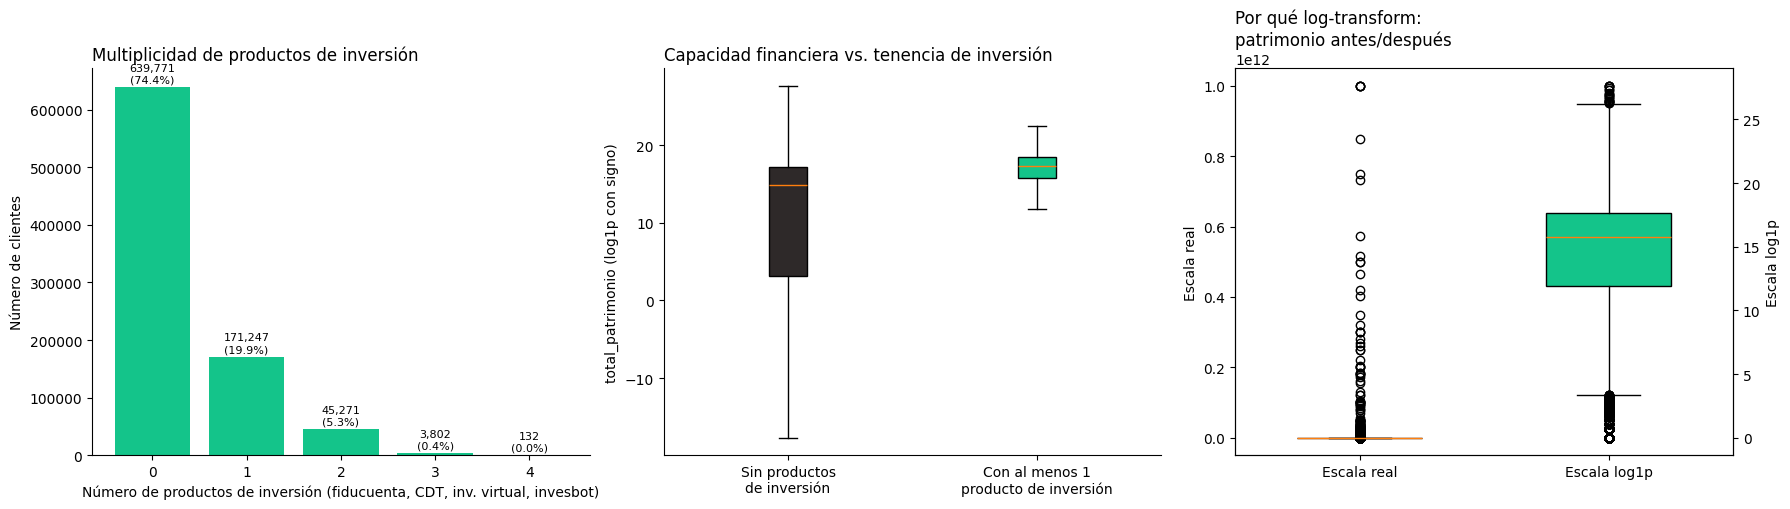

In [ ]:
n_productos = (
    df_abt_crean["tiene_fiducuenta"] + df_abt_crean["tiene_cdt"]
    + df_abt_crean["tiene_inv_virtual"] + df_abt_crean["tiene_invesbot"]
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))

conteo = n_productos.value_counts().sort_index()
axes[0].bar(conteo.index.astype(str), conteo.values, color=PRINCIPAL)
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 8000, f"{v:,}\n({v/len(df_abt_crean)*100:.1f}%)", ha="center", fontsize=8)
axes[0].set_xlabel("Número de productos de inversión (fiducuenta, CDT, inv. virtual, invesbot)")
axes[0].set_ylabel("Número de clientes")
axes[0].set_title("Multiplicidad de productos de inversión", fontsize=12, loc="left")
axes[0].spines[["top","right"]].set_visible(False)

patrimonio_log = np.sign(df_abt_crean["total_patrimonio"]) * np.log1p(np.abs(df_abt_crean["total_patrimonio"]))
grupo_con = patrimonio_log[(n_productos > 0).values].dropna()
grupo_sin = patrimonio_log[(n_productos == 0).values].dropna()
bp_plot2 = axes[1].boxplot([grupo_sin.values, grupo_con.values], tick_labels=["Sin productos\nde inversión", "Con al menos 1\nproducto de inversión"], showfliers=False, patch_artist=True)
bp_plot2["boxes"][0].set_facecolor(ATENUADO)
bp_plot2["boxes"][1].set_facecolor(PRINCIPAL)
axes[1].set_ylabel("total_patrimonio (log1p con signo)")
axes[1].set_title("Capacidad financiera vs. tenencia de inversión", fontsize=12, loc="left")
axes[1].spines[["top","right"]].set_visible(False)

raw = df_abt_crean["total_patrimonio"].clip(lower=0).dropna()
log_raw = np.log1p(raw)
bp1 = axes[2].boxplot([raw.values], positions=[0], widths=0.5, showfliers=True, patch_artist=True)
bp1["boxes"][0].set_facecolor(ATENUADO)
axes[2].set_ylabel("Escala real")
ax2b = axes[2].twinx()
bp2 = ax2b.boxplot([log_raw.values], positions=[1], widths=0.5, showfliers=True, patch_artist=True)
bp2["boxes"][0].set_facecolor(PRINCIPAL)
ax2b.set_ylabel("Escala log1p")
axes[2].set_xlim(-0.5, 1.5)
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(["Escala real", "Escala log1p"])
axes[2].set_title("Por qué log-transform:\npatrimonio antes/después", fontsize=12, loc="left")
axes[2].spines[["top"]].set_visible(False)

plt.tight_layout()
plt.show()

**Multiplicidad de productos:**
De cada 100 clientes del banco, 74 no tienen ningún producto de inversión, 20 tienen uno solo, y apenas 5 combinan dos o más (y solo un puñado tiene tres o cuatro). O sea: la inmensa mayoría de la base todavía no ha probado ningún producto de inversión — ahí está el terreno donde puede crecer la nueva app.

**Capacidad financiera vs. tenencia de inversión:**
Los clientes que ya tienen algún producto de inversión son, en general, más "pudientes" que los que no — la caja de la derecha está claramente más arriba que la de la izquierda. En plata real, el cliente típico que ya invierte tiene unas 11 veces más patrimonio que el que no invierte (34 millones frente a 3 millones). Confirma algo bastante intuitivo: quien tiene más plata disponible es más probable que ya esté invirtiendo — y por eso el patrimonio va a pesar mucho a la hora de decidir a quién ofrecerle la app.

**Por qué "comprimir" el patrimonio antes de analizarlo:**
A la izquierda se ve el patrimonio tal cual, en pesos reales — y casi no se distingue nada, porque unos pocos clientes con patrimonios enormes (miles de millones) estiran tanto el gráfico que todos los demás quedan aplastados contra el piso. A la derecha se aplicó una transformación que comprime esa escala; ahí sí se alcanza a ver cómo se distribuye realmente el patrimonio de la mayoría de los clientes, no solo de los pocos extremos. No es decoración: si se usara el patrimonio "crudo" en cualquier análisis o modelo, esos pocos clientes extremos dominarían el resultado y esconderían el comportamiento de los demás 860,000.

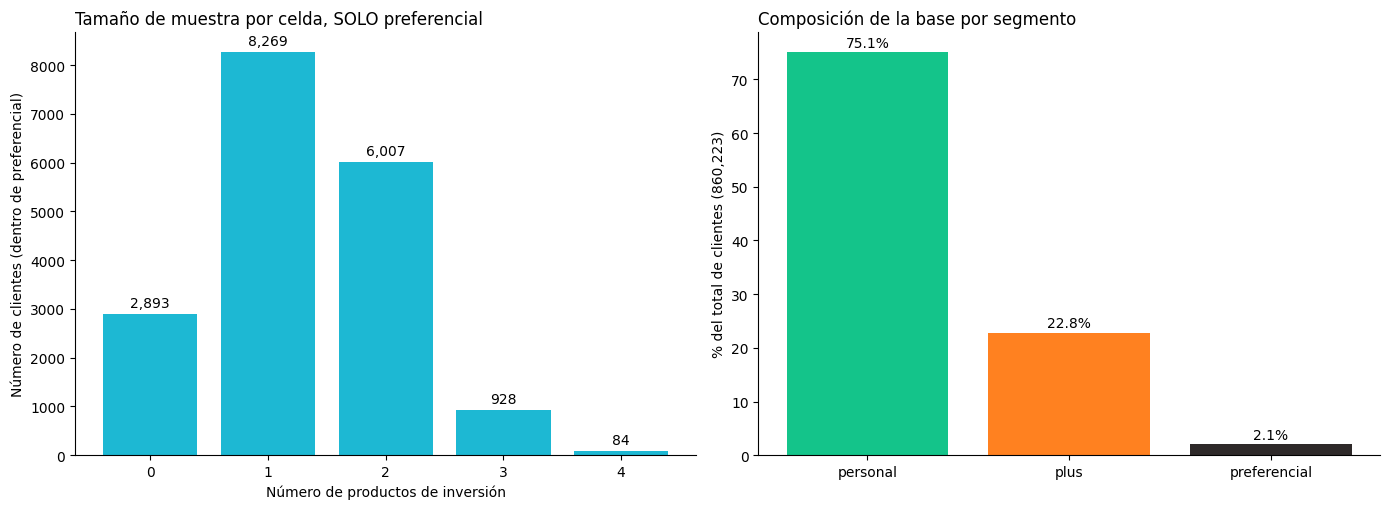

In [ ]:
n_productos = (
    df_abt_crean["tiene_fiducuenta"] + df_abt_crean["tiene_cdt"]
    + df_abt_crean["tiene_inv_virtual"] + df_abt_crean["tiene_invesbot"]
)

muestra_pref = df_abt_crean.loc[df_abt_crean["desc_segmento"]=="preferencial"].groupby(n_productos).size()
seg_pct = df_abt_crean["desc_segmento"].value_counts() / len(df_abt_crean) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

bars0 = axes[0].bar(muestra_pref.index.astype(str), muestra_pref.values, color=PALETA['azul'])
for bar, v in zip(bars0, muestra_pref.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 150, f"{v:,}", ha="center", fontsize=10)
axes[0].set_xlabel("Número de productos de inversión")
axes[0].set_ylabel("Número de clientes (dentro de preferencial)")
axes[0].set_title("Tamaño de muestra por celda, SOLO preferencial", fontsize=12, loc="left")
axes[0].spines[["top","right"]].set_visible(False)

colores = {"personal": PRINCIPAL, "plus": ALERTA, "preferencial": ATENUADO}
bars1 = axes[1].bar(seg_pct.index, seg_pct.values, color=[colores[s] for s in seg_pct.index])
for bar, v in zip(bars1, seg_pct.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 1, f"{v:.1f}%", ha="center", fontsize=10)
axes[1].set_ylabel("% del total de clientes (860,223)")
axes[1].set_title("Composición de la base por segmento", fontsize=12, loc="left")
axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

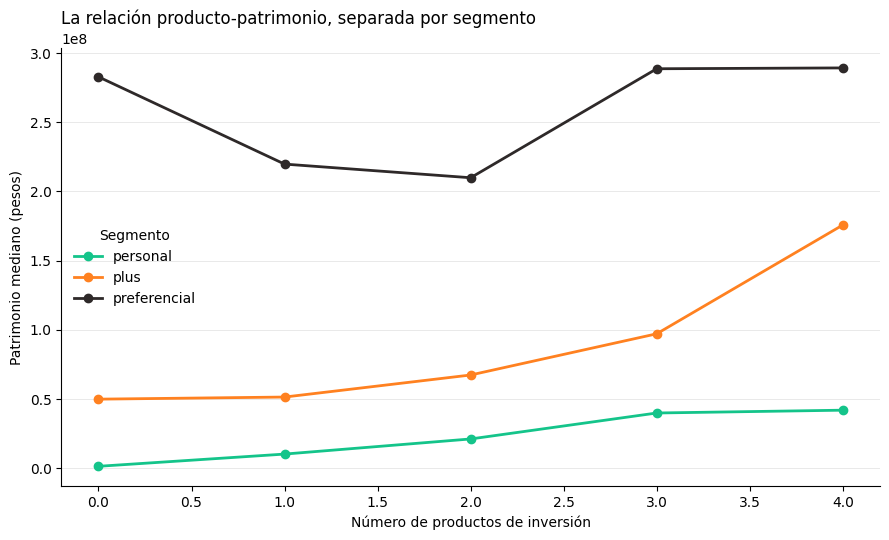

In [ ]:
n_productos = (
    df_abt_crean["tiene_fiducuenta"] + df_abt_crean["tiene_cdt"]
    + df_abt_crean["tiene_inv_virtual"] + df_abt_crean["tiene_invesbot"]
)

tabla = df_abt_crean.groupby(["desc_segmento", n_productos])["total_patrimonio"].median().unstack()

fig, ax = plt.subplots(figsize=(9, 5.5))
colores = {"personal": PRINCIPAL, "plus": ALERTA, "preferencial": ATENUADO}
for seg in tabla.index:
    ax.plot(tabla.columns, tabla.loc[seg], marker="o", label=seg, color=colores.get(seg), linewidth=2)
ax.set_xlabel("Número de productos de inversión")
ax.set_ylabel("Patrimonio mediano (pesos)")
ax.set_title("La relación producto-patrimonio, separada por segmento", fontsize=12, loc="left")
ax.legend(title="Segmento", frameon=False)
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", color="#E5E5E5", linewidth=0.6)
plt.tight_layout()
plt.show()

En "preferencial" el patrimonio no sube de forma pareja porque es un segmento chico y ya de por sí muy rico. Los que no tienen ningún producto de inversión ya son ricos por otras vías (propiedades, negocios), así que no necesitan estos productos para tener patrimonio alto — por eso ahí arranca más alto de lo esperado y baja un poco al agregar 1-2 productos. Y el salto final a 3-4 productos hay que tomarlo con pinzas: son solo 928 y 84 clientes, muestras chicas donde unos pocos casos extremos mueven el número fácilmente. En resumen: no es que el patrón esté mal, es que este segmento es demasiado chico y homogéneamente rico para que el número de productos siga diciendo algo nuevo — la relación fuerte y confiable vive en "personal" y "plus", el 98% de tus clientes.

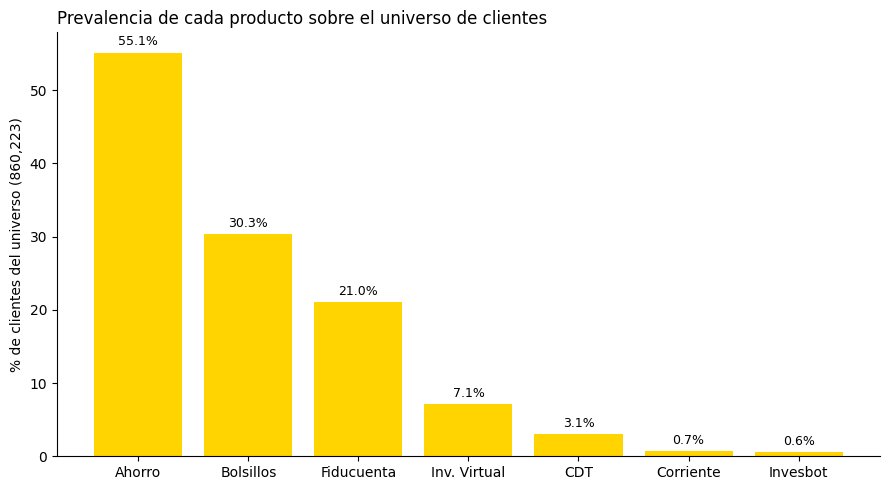

In [ ]:
prevalencia = {
    "Ahorro": df_abt_crean["tiene_ahorro"].mean() * 100,
    "Bolsillos": df_abt_crean["tiene_bolsillos"].mean() * 100,
    "Fiducuenta": df_abt_crean["tiene_fiducuenta"].mean() * 100,
    "Inv. Virtual": df_abt_crean["tiene_inv_virtual"].mean() * 100,
    "CDT": df_abt_crean["tiene_cdt"].mean() * 100,
    "Corriente": df_abt_crean["tiene_corriente"].mean() * 100,
    "Invesbot": df_abt_crean["tiene_invesbot"].mean() * 100,
}
prevalencia = dict(sorted(prevalencia.items(), key=lambda x: -x[1]))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(prevalencia.keys(), prevalencia.values(), color=[PALETA['verde'], PALETA['azul'], PALETA['naranja'], PALETA['violeta'], PALETA['rosa'], PALETA['amarillo'], PALETA['negro']])
for bar, v in zip(bars, prevalencia.values()):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1, f"{v:.1f}%", ha="center", fontsize=9)
ax.set_ylabel("% de clientes del universo (860,223)")
ax.set_title("Prevalencia de cada producto sobre el universo de clientes", fontsize=12, loc="left")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

ahorro (55%) y bolsillos (30%) los tiene medio banco. Pero baja rapidísimo: inversión virtual (7%), CDT (3%), Invesbot (0.6%) — son productos de nicho, casi nadie los tiene todavía. Se identifica cuáles productos son "masivos" (todo el mundo los usa, no distinguen mucho entre clientes) y cuáles son "raros pero reveladores" (si un cliente tiene uno de estos, dice mucho de su perfil). Eso ayuda a decidir qué variables van a pesar más quando se agrupe a los clientes. Las 4 gráficas, juntas, arman la justificación de que (1) hay una oportunidad real de negocio (mucha gente sin invertir), (2) la plata predice la inversión, (3) hay que preparar los datos antes de modelar, y (4) no todos los productos valen lo mismo como señal. Es la evidencia que sostiene por qué se va construir el clustering.

In [ ]:
nombres = ["ahorro", "corriente", "bolsillos", "fiducuenta", "cdt", "inv_virtual", "invesbot"]
cols_tiene = [f"tiene_{n}" for n in nombres]

In [ ]:
# 1. Co-ocurrencia: de los que tienen A, % que tambien tiene B
co_ocurrencia = pd.DataFrame(index=nombres, columns=nombres, dtype=float)
for a in nombres:
    tiene_a = df_abt_crean[f"tiene_{a}"] == 1
    n_a = tiene_a.sum()
    for b in nombres:
        co_ocurrencia.loc[a, b] = (df_abt_crean.loc[tiene_a, f"tiene_{b}"] == 1).sum() / n_a * 100

# 2. Tenencia por segmento
tenencia_segmento = df_abt_crean.groupby("desc_segmento")[cols_tiene].mean() * 100
tenencia_segmento.columns = nombres

# 3. Tenencia por grupo de edad
tenencia_edad = df_abt_crean.groupby("grupo_edad")[cols_tiene].mean() * 100
tenencia_edad.columns = nombres

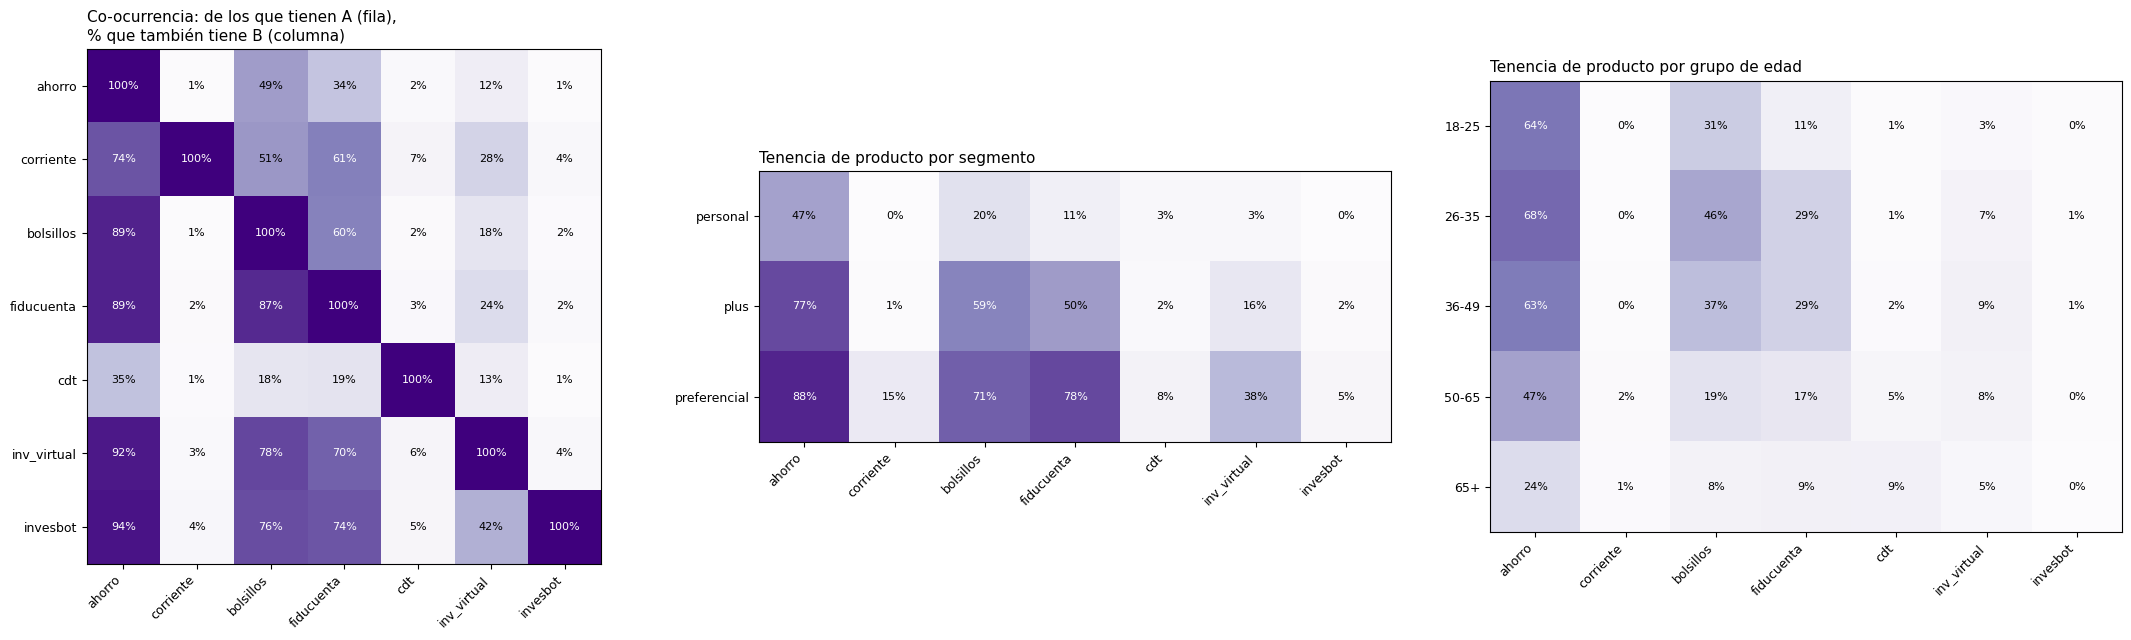

In [ ]:
def heatmap(ax, data, titulo):
    im = ax.imshow(data.values.astype(float), cmap="Purples", vmin=0, vmax=100)
    ax.set_xticks(range(len(data.columns))); ax.set_yticks(range(len(data.index)))
    ax.set_xticklabels(data.columns, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(data.index, fontsize=9)
    for i in range(len(data.index)):
        for j in range(len(data.columns)):
            v = data.values[i, j]
            ax.text(j, i, f"{v:.0f}%", ha="center", va="center", fontsize=8, color="white" if v>55 else "black")
    ax.set_title(titulo, fontsize=11, loc="left")

fig, axes = plt.subplots(1, 3, figsize=(22, 6.5))
heatmap(axes[0], co_ocurrencia, "Co-ocurrencia: de los que tienen A (fila),\n% que también tiene B (columna)")
heatmap(axes[1], tenencia_segmento, "Tenencia de producto por segmento")
heatmap(axes[2], tenencia_edad, "Tenencia de producto por grupo de edad")
plt.tight_layout()
plt.show()


Co-ocurrencia: el CDT es el más "solitario" — solo el 35% de quienes tienen CDT también tiene ahorro, muy por debajo del 74-94% que se ve en las demás filas. Confirma otra vez que el cliente de CDT es un perfil aparte, no el típico cliente bancario. En el extremo opuesto, Invesbot es el más "acompañado": 94% de sus usuarios ya tiene ahorro, 76% bolsillos, 74% fiducuenta — quien llega a Invesbot ya viene con un perfil financiero activo, no es alguien que empieza de cero.

Tenencia por segmento: casi todos los productos escalan de forma ordenada personal → plus → preferencial, pero corriente es el caso más extremo: 0.1% en personal, apenas 1.2% en plus, y salta a 14.5% en preferencial — es prácticamente un producto exclusivo del segmento más alto. Esta gráfica es literalmente un adelanto de cómo se van a ver tus clusters antes de correrlos.

Tenencia por grupo de edad: aquí aparece el patrón más interesante — ahorro y bolsillos son productos de gente joven/madura (pico en 26-35, caen fuerte después de los 65), mientras que CDT hace exactamente lo contrario: sube con la edad, de 0.5% en 18-25 a 9.0% en 65+. Confirma con evidencia lo que habíamos intuido antes: CDT es el producto de inversión "tradicional" de clientes mayores, mientras que inversión virtual e invesbot (los más "digitales") pesan más en el rango medio (36-49), no en los más jóvenes — probablemente porque a los 18-25 todavía no tienen suficiente capital para invertir, sin importar qué tan cómodos estén con la tecnología.

## Tamaño de la oportunidad de negocio

Con la evidencia de las secciones anteriores — la mayoría de la base no tiene productos de inversión, y quien sí los tiene concentra más patrimonio —, esta sección convierte esa evidencia en un número concreto de negocio: cuántos clientes son candidatos prioritarios (ya tienen la capacidad financiera, todavía no tienen el producto) y qué tan grande es esa oportunidad en pesos. Ese número se reporta ya winsorizado, no como un paso adicional sino porque una suma es mucho más sensible a un puñado de clientes extremadamente ricos que una mediana — sin ese tratamiento, la cifra que se lleva a negocio quedaría inflada por concentración, no por volumen real distribuido entre los prospectos. Junto a esto se revisa también qué tan confiable es el ingreso declarado de los clientes (`perfil_ingreso`): la capacidad financiera que sostiene esta oportunidad depende en parte de ese dato, así que vale la pena verificar aquí, antes de avanzar a seleccionar variables para el clustering, si el ingreso declarado es consistente con el estimado o si hay una brecha sistemática que haya que tener en cuenta.

In [ ]:
p90_patrimonio = df_abt_crean["total_patrimonio"].quantile(0.90)
p99_patrimonio = df_abt_crean["total_patrimonio"].quantile(0.99)
n_productos = (
    df_abt_crean["tiene_fiducuenta"] + df_abt_crean["tiene_cdt"]
    + df_abt_crean["tiene_inv_virtual"] + df_abt_crean["tiene_invesbot"]
)

prospectos = df_abt_crean[
    (n_productos == 0) & (df_abt_crean["tiene_invesbot"] == 0) & (df_abt_crean["total_patrimonio"] >= p90_patrimonio)
].copy()

prospectos["total_patrimonio_wz"] = prospectos["total_patrimonio"].clip(upper=p99_patrimonio)

print(f"Prospectos prioritarios: {len(prospectos):,} ({len(prospectos)/len(df_abt_crean)*100:.1f}% de la base)")
print(f"Patrimonio mediano: {prospectos['total_patrimonio'].median():,.0f}")
print(f"Volumen total winsorizado: {prospectos['total_patrimonio_wz'].sum():,.0f}")
print(prospectos["desc_segmento"].value_counts())


Prospectos prioritarios: 43,608 (5.1% de la base)
Patrimonio mediano: 242,544,000
Volumen total winsorizado: 13,307,247,141,636
desc_segmento
plus            21185
personal        20397
preferencial     2026
Name: count, dtype: int64


In [ ]:
p99_ing = df_abt_crean["ingresos_mensuales"].quantile(0.99)
df_abt_crean["ingresos_mensuales_wz"] = df_abt_crean["ingresos_mensuales"].clip(upper=p99_ing)

print("=== Distribución de perfil_ingreso ===")
print(df_abt_crean["perfil_ingreso"].value_counts())
print()
print("=== Patrimonio mediano por perfil_ingreso ===")
print(df_abt_crean.groupby("perfil_ingreso")["total_patrimonio"].median().sort_values())
print()
print("=== % de cada perfil dentro de cada segmento ===")
print(pd.crosstab(df_abt_crean["desc_segmento"], df_abt_crean["perfil_ingreso"], normalize="index") * 100)

=== Distribución de perfil_ingreso ===
perfil_ingreso
consistente     440855
subdeclara      242266
sin_dato        114431
sobredeclara     62671
Name: count, dtype: int64

=== Patrimonio mediano por perfil_ingreso ===
perfil_ingreso
sin_dato          950000.0
subdeclara       2529945.0
consistente     13727270.0
sobredeclara    19000000.0
Name: total_patrimonio, dtype: float64

=== % de cada perfil dentro de cada segmento ===
perfil_ingreso  consistente   sin_dato  sobredeclara  subdeclara
desc_segmento                                                   
personal          42.965463  16.269641      5.506757   35.258139
plus              76.674895   4.659003     13.447611    5.218491
preferencial      71.354711   1.094549      4.026181   23.524559


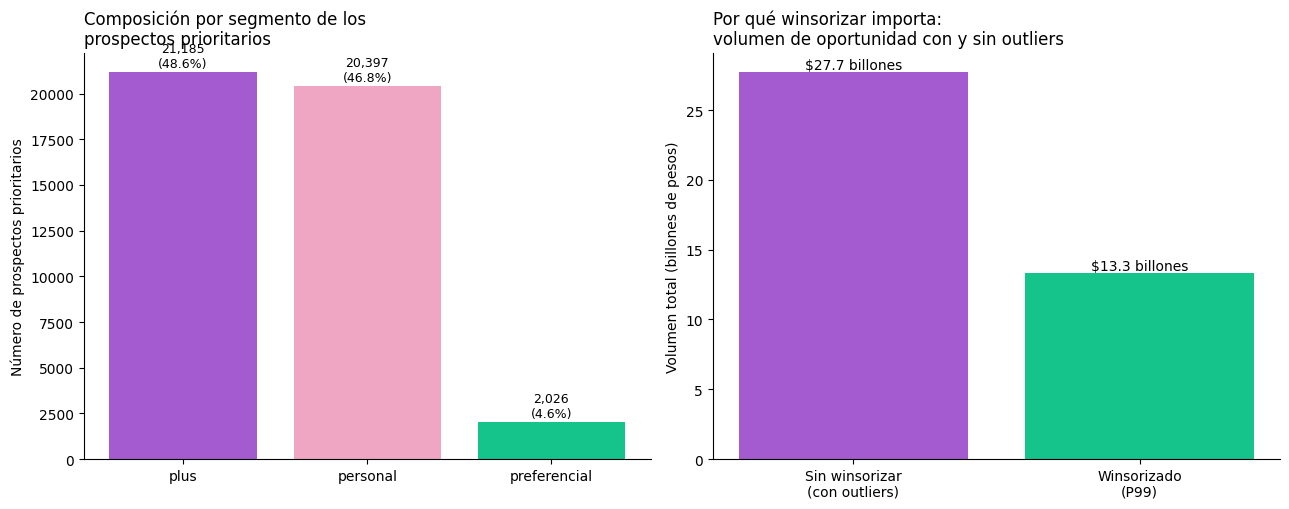

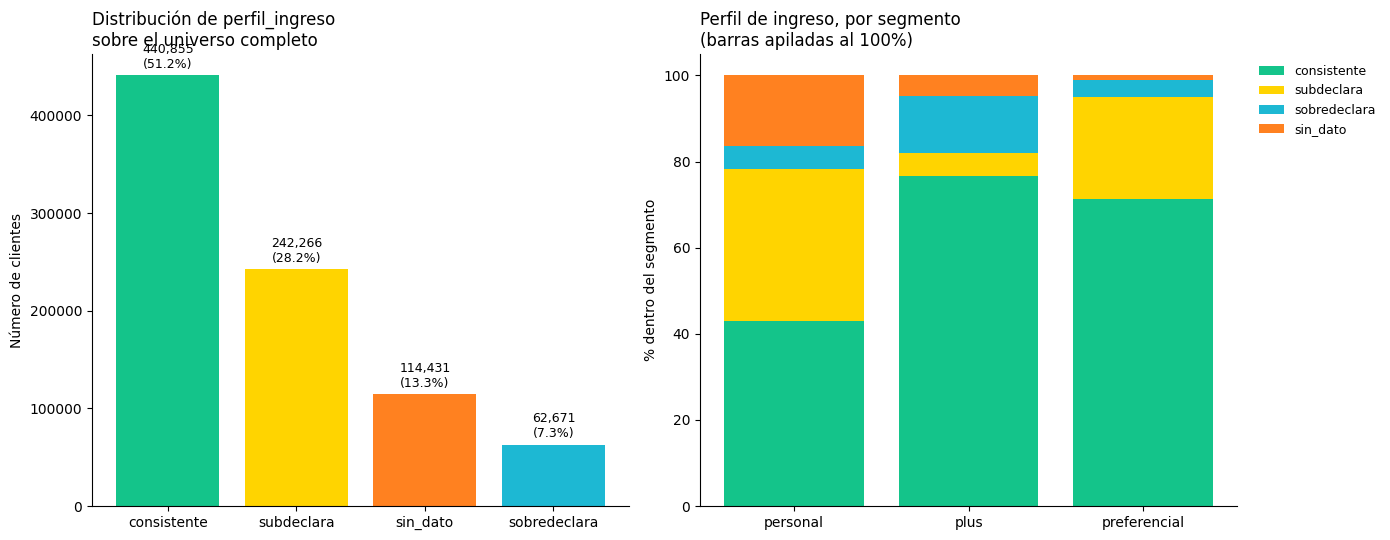

In [ ]:
fig1, axes1 = plt.subplots(1, 2, figsize=(13, 5.2))

comp_segmento = prospectos["desc_segmento"].value_counts()
colores_segmento = {"plus": PALETA['violeta'], "personal": PALETA['rosa'], "preferencial": PALETA['verde']}
bars = axes1[0].bar(comp_segmento.index, comp_segmento.values, color=[colores_segmento[s] for s in comp_segmento.index])
for bar, v in zip(bars, comp_segmento.values):
    axes1[0].text(bar.get_x() + bar.get_width()/2, v + 300, f"{v:,}\n({v/len(prospectos)*100:.1f}%)", ha="center", fontsize=9)
axes1[0].set_ylabel("Número de prospectos prioritarios")
axes1[0].set_title("Composición por segmento de los\nprospectos prioritarios", fontsize=12, loc="left")
axes1[0].spines[["top","right"]].set_visible(False)

volumen = pd.Series({
    "Sin winsorizar\n(con outliers)": prospectos["total_patrimonio"].sum(),
    "Winsorizado\n(P99)": prospectos["total_patrimonio_wz"].sum(),
})
bars2 = axes1[1].bar(volumen.index, volumen.values / 1e12, color=[PALETA['violeta'], PRINCIPAL])
for bar, v in zip(bars2, volumen.values):
    axes1[1].text(bar.get_x() + bar.get_width()/2, v/1e12, f"${v/1e12:,.1f} billones", ha="center", va="bottom", fontsize=10)
axes1[1].set_ylabel("Volumen total (billones de pesos)")
axes1[1].set_title("Por qué winsorizar importa:\nvolumen de oportunidad con y sin outliers", fontsize=12, loc="left")
axes1[1].spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5.5))

conteo_perfil = df_abt_crean["perfil_ingreso"].value_counts()
colores_perfil = {"consistente": PRINCIPAL, "subdeclara": PALETA['amarillo'], "sin_dato": PALETA['naranja'], "sobredeclara": PALETA['azul']}
bars3 = axes2[0].bar(conteo_perfil.index, conteo_perfil.values, color=[colores_perfil[c] for c in conteo_perfil.index])
for bar, v in zip(bars3, conteo_perfil.values):
    axes2[0].text(bar.get_x() + bar.get_width()/2, v + 8000, f"{v:,}\n({v/len(df_abt_crean)*100:.1f}%)", ha="center", fontsize=9)
axes2[0].set_ylabel("Número de clientes")
axes2[0].set_title("Distribución de perfil_ingreso\nsobre el universo completo", fontsize=12, loc="left")
axes2[0].spines[["top","right"]].set_visible(False)

cruce = pd.crosstab(df_abt_crean["desc_segmento"], df_abt_crean["perfil_ingreso"], normalize="index") * 100
cruce = cruce[["consistente", "subdeclara", "sobredeclara", "sin_dato"]]
bottom = np.zeros(len(cruce))
for col in cruce.columns:
    axes2[1].bar(cruce.index, cruce[col], bottom=bottom, label=col, color=colores_perfil[col])
    bottom += cruce[col].values
axes2[1].set_ylabel("% dentro del segmento")
axes2[1].set_title("Perfil de ingreso, por segmento\n(barras apiladas al 100%)", fontsize=12, loc="left")
axes2[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False, fontsize=9)
axes2[1].spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

Composición por segmento: plus (48.6%) y personal (46.8%) aportan casi todos los prospectos prioritarios, casi empatados; preferencial casi no tiene (4.6%) porque ya está saturado de productos de inversión — confirma que la oportunidad está concentrada en los segmentos medios, no en el más alto.

Con vs. sin winsorizar: la barra sin winsorizar (76.3 billones) es 5.7 veces más grande que la real (13.3 billones) — evidencia visual directa de por qué reportar la cifra sin corregir sería un error grave en la sustentación.

Distribución de perfil_ingreso: "consistente" es el más común (41.5%), pero "subdeclara" no se queda atrás (33.8%) — es un fenómeno amplio, no marginal, y vale la pena investigarlo más.

Perfil por segmento (barras apiladas): aquí se ve clarísimo el hallazgo contraintuitivo la franja dorada (subdeclara) es enorme en personal ( aprox 42%) y se reduce mucho en plus (aprox 9%) y preferencial (aprox 14%). Confirma visualmente que "subdeclarar" es un fenómeno concentrado en el segmento de menor patrimonio, no una señal de riqueza oculta en los segmentos altos.

## Selección de variables para clustering

Criterios aplicados, en orden:
1. **Redundancia**: correlación de Spearman entre candidatas dentro de su mismo bloque (capacidad, magnitud, tenencia). Si dos variables correlacionan fuerte, se descarta la que aporta menos información nueva.
2. **Poder de discriminación de tenencia**: ¿el patrimonio mediano difiere entre quien tiene el producto y quien no?
3. **Poder de discriminación de magnitud**: dentro de los que ya tienen el producto, ¿el nivel del saldo también distingue patrimonio?
4. **Prevalencia práctica**: una bandera con prevalencia extrema (<1% o >90%) pesa muy poco en la distancia euclidiana de K-means sobre 860k filas, sin importar qué tan grande sea su gap. Se reserva para perfilar clusters después, no para la distancia.


### Correlación por bloques

In [ ]:
bloque_capacidad = df_abt_crean[["total_patrimonio", "ingresos_mensuales_wz",
                         "total_activos", "total_pasivos", "total_egresos_mensuales"]]

bloque_magnitud = df_abt_crean[["saldo_ahorro_mediana_historica", "saldo_corriente_mediana_historica",
                        "saldo_bolsillos_mediana_historica", "saldo_fiducuenta_mediana_historica",
                        "saldo_cdt_mediana_historica", "saldo_inversion_virtual_mediana_historica",
                        "saldo_invesbot_mediana_historica"]]

bloque_tenencia = df_abt_crean[["tiene_ahorro", "tiene_corriente", "tiene_bolsillos",
                        "tiene_fiducuenta", "tiene_cdt", "tiene_inv_virtual", "tiene_invesbot"]]

corr_capacidad = bloque_capacidad.rank().corr()
corr_magnitud = bloque_magnitud.rank().corr()
corr_tenencia = bloque_tenencia.corr()

def plot_heatmap(corr, titulo, ax):
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(corr.columns, fontsize=8)
    for i in range(len(corr.columns)):
        for j in range(len(corr.columns)):
            ax.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center", fontsize=7,
                     color="white" if abs(corr.values[i, j]) > 0.6 else "black")
    ax.set_title(titulo, fontsize=11, loc="left")
    return im

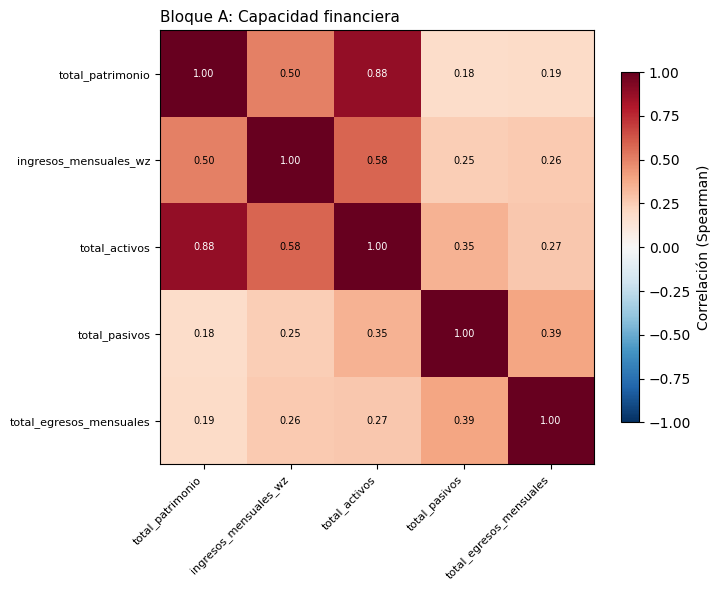

In [ ]:
# Heatmap para Bloque A: Capacidad financiera
fig_capacidad, ax_capacidad = plt.subplots(figsize=(7, 6.5))
im_capacidad = plot_heatmap(corr_capacidad, "Bloque A: Capacidad financiera", ax_capacidad)
fig_capacidad.colorbar(im_capacidad, ax=ax_capacidad, shrink=0.7, label="Correlación (Spearman)")
plt.savefig("correlacion_capacidad.png", dpi=110, bbox_inches="tight")
plt.show()

Esta matriz muestra qué tan relacionadas están entre sí las variables que reflejan la capacidad financiera de los clientes. Se destaca una relación muy fuerte entre el patrimonio total y los activos totales, lo cual es esperable, ya que gran parte de lo que una persona posee constituye precisamente su patrimonio. También existe una relación moderada entre los ingresos mensuales y tanto el patrimonio como los activos, lo que indica que quienes ganan más tienden a acumular más bienes, aunque no de manera tan estrecha como la relación anterior.

En contraste, los pasivos y los egresos mensuales muestran una relación baja con el patrimonio y los activos, lo que sugiere que el nivel de endeudamiento o de gasto de una persona no depende tanto de cuánto posee. Entre pasivos y egresos mensuales sí se observa una relación algo más notoria, lo cual tiene sentido porque las deudas suelen generar pagos periódicos que impactan los gastos. En general, el patrimonio y los activos se comportan casi como una misma medida, mientras que las obligaciones financieras siguen una lógica más independiente del resto de las variables.

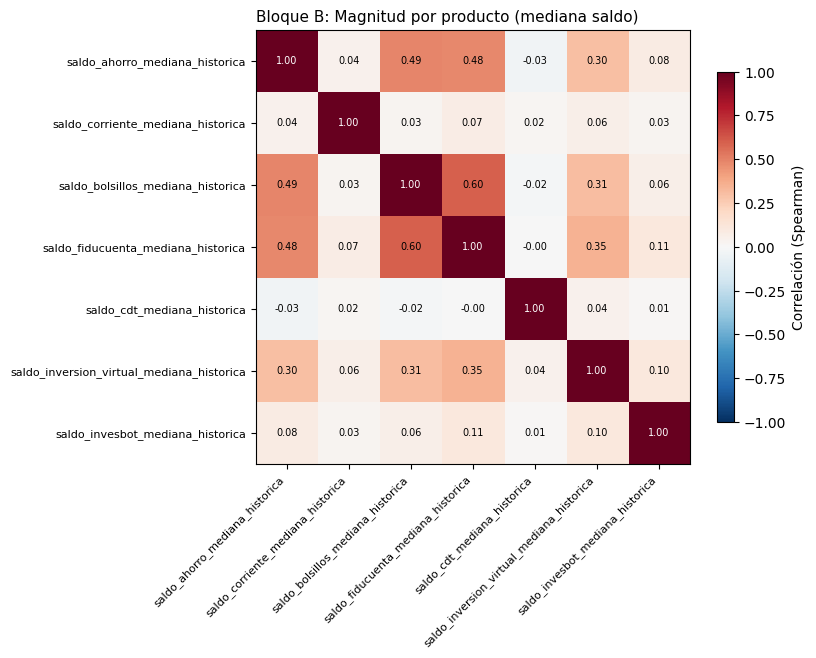

In [ ]:
# Heatmap para Bloque B: Magnitud por producto (mediana saldo)
fig_magnitud, ax_magnitud = plt.subplots(figsize=(7, 6.5))
im_magnitud = plot_heatmap(corr_magnitud, "Bloque B: Magnitud por producto (mediana saldo)", ax_magnitud)
fig_magnitud.colorbar(im_magnitud, ax=ax_magnitud, shrink=0.7, label="Correlación (Spearman)")
plt.savefig("correlacion_magnitud.png", dpi=110, bbox_inches="tight")
plt.show()

Esta matriz analiza si los clientes que mantienen saldos altos en un producto también tienden a mantener saldos altos en los demás. Se observa una relación moderada entre el saldo de bolsillos, el de Fiducuenta y el de ahorros, lo que sugiere que estos tres productos comparten un perfil similar de cliente: quienes manejan montos considerables en uno de ellos suelen hacerlo también en los otros. Esto podría reflejar hábitos de ahorro consistentes o el uso de varios productos como parte de una misma estrategia financiera.

Por otro lado, el saldo de cuenta corriente y el de CDT prácticamente no muestran relación con ningún otro producto, lo que indica que los clientes que usan estos productos lo hacen de forma independiente, sin que ello se relacione con sus saldos en ahorros u otros instrumentos. La inversión virtual muestra una conexión leve con Fiducuenta y bolsillos, mientras que Invesbot se mantiene bastante aislado del resto. En conjunto, la información sugiere que existen dos grupos de comportamiento: uno de productos de ahorro que se mueven juntos, y otro de productos más transaccionales o especializados que operan de manera independiente.

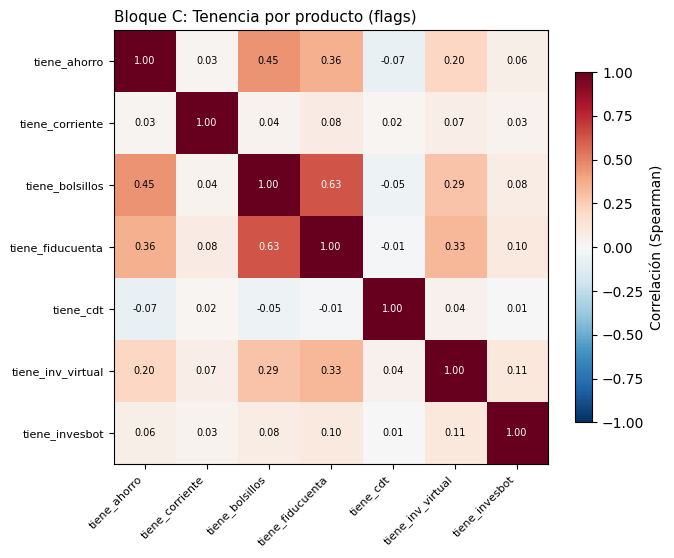

In [ ]:
# Heatmap para Bloque C: Tenencia por producto (flags)
fig_tenencia, ax_tenencia = plt.subplots(figsize=(7, 6.5))
im_tenencia = plot_heatmap(corr_tenencia, "Bloque C: Tenencia por producto (flags)", ax_tenencia)
fig_tenencia.colorbar(im_tenencia, ax=ax_tenencia, shrink=0.7, label="Correlación (Spearman)")
plt.savefig("correlacion_tenencia.png", dpi=110, bbox_inches="tight")
plt.show()

A diferencia de las gráficas anteriores, que miraban montos, esta analiza si el hecho de tener un producto está relacionado con tener otros, sin importar el saldo. Aquí se destaca con claridad que tener bolsillos y tener Fiducuenta están fuertemente asociados: quien posee uno de estos productos tiene una alta probabilidad de poseer también el otro. También hay una relación notable entre tener ahorros y tener bolsillos, así como entre ahorros y Fiducuenta, lo que confirma que estos tres productos suelen adquirirse en conjunto, probablemente porque forman parte de una misma oferta o hábito de uso dentro de la entidad.

En cambio, tener cuenta corriente o tener CDT no muestra relación relevante con la tenencia de ningún otro producto, lo que indica que estos se contratan de manera independiente. Tener CDT incluso presenta una leve relación negativa con ahorros y bolsillos, sugiriendo que son perfiles de cliente algo distintos. La inversión virtual y Invesbot muestran conexiones más débiles con el resto, aunque la inversión virtual sí guarda cierta cercanía con Fiducuenta y bolsillos. En resumen, existe un núcleo de productos (ahorro, bolsillos y Fiducuenta) que tienden a combinarse entre sí, mientras que los demás productos se comportan de forma más autónoma.

### Evidencia de discriminación (tenencia y magnitud)

In [ ]:
productos = ["ahorro", "corriente", "bolsillos", "fiducuenta", "cdt", "inv_virtual", "invesbot"]
nombre_saldo = {"inv_virtual": "inversion_virtual"}  # única columna con nombre distinto al flag

evidencia_tenencia = []
for p in productos:
    con = df_abt_crean.loc[df_abt_crean[f"tiene_{p}"] == 1, "total_patrimonio"]
    sin = df_abt_crean.loc[df_abt_crean[f"tiene_{p}"] == 0, "total_patrimonio"]
    evidencia_tenencia.append({
        "producto": p,
        "prevalencia_%": df_abt_crean[f"tiene_{p}"].mean() * 100,
        "patrimonio_mediano_con": con.median(),
        "patrimonio_mediano_sin": sin.median(),
        "gap_multiplicador": con.median() / sin.median() if sin.median() > 0 else np.nan,
    })
tabla_tenencia = pd.DataFrame(evidencia_tenencia).set_index("producto").sort_values("gap_multiplicador")

evidencia_magnitud = []
productos_con_saldo = [p for p in productos if p not in ("ahorro", "corriente")]
for p in productos_con_saldo:
    col_saldo = f"saldo_{nombre_saldo.get(p, p)}_mediana_historica"
    holders = df_abt_crean[df_abt_crean[f"tiene_{p}"] == 1]
    corte = holders[col_saldo].median()
    altos = holders[holders[col_saldo] >= corte]
    bajos = holders[holders[col_saldo] < corte]
    evidencia_magnitud.append({
        "producto": p, "n_holders": len(holders),
        "patrimonio_si_saldo_alto": altos["total_patrimonio"].median(),
        "patrimonio_si_saldo_bajo": bajos["total_patrimonio"].median(),
        "gap_magnitud": altos["total_patrimonio"].median() / bajos["total_patrimonio"].median(),
    })
tabla_magnitud = pd.DataFrame(evidencia_magnitud).set_index("producto").sort_values("gap_magnitud")

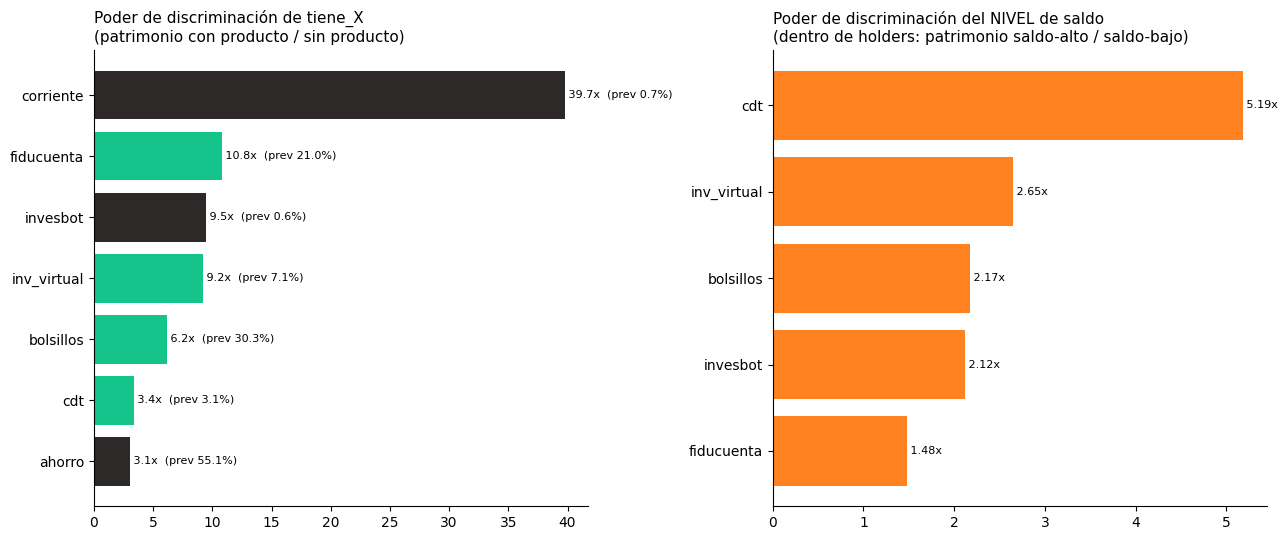

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

colores_a = [ATENUADO if p in ("corriente", "ahorro", "invesbot") else PRINCIPAL for p in tabla_tenencia.index]
axes[0].barh(tabla_tenencia.index, tabla_tenencia["gap_multiplicador"], color=colores_a)
for i, (p, v) in enumerate(tabla_tenencia["gap_multiplicador"].items()):
    axes[0].text(v, i, f" {v:.1f}x  (prev {tabla_tenencia.loc[p,'prevalencia_%']:.1f}%)", va="center", fontsize=8)
axes[0].set_title("Poder de discriminación de tiene_X\n(patrimonio con producto / sin producto)", fontsize=11, loc="left")
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].barh(tabla_magnitud.index, tabla_magnitud["gap_magnitud"], color=ALERTA)
for i, (p, v) in enumerate(tabla_magnitud["gap_magnitud"].items()):
    axes[1].text(v, i, f" {v:.2f}x", va="center", fontsize=8)
axes[1].set_title("Poder de discriminación del NIVEL de saldo\n(dentro de holders: patrimonio saldo-alto / saldo-bajo)", fontsize=11, loc="left")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("evidencia_seleccion_variables.png", dpi=110)
plt.show()

Este par de gráficas muestra qué tanto ayuda cada producto a distinguir el nivel de patrimonio de un cliente. En la gráfica izquierda, tener cuenta corriente resalta enormemente: quienes la poseen tienen en promedio casi 40 veces más patrimonio que quienes no la tienen. Sin embargo, hay que tomar este dato con cautela, ya que solo el 0.7% de los clientes cuenta con este producto, por lo que se trata de un grupo muy reducido y probablemente compuesto por clientes de perfil alto o empresarial. Le siguen Fiducuenta, Invesbot e inversión virtual, con diferencias de patrimonio moderadas y más representativas, mientras que ahorro y bolsillos, pese a ser los productos más comunes entre los clientes, son los que menos distinguen el nivel de patrimonio, ya que los tiene prácticamente cualquier tipo de cliente.

En la gráfica derecha se analiza algo distinto: entre quienes ya tienen cada producto, qué tanto separa el nivel de saldo alto del saldo bajo. Aquí el CDT se destaca como el producto que mejor diferencia a los clientes con más recursos de los que tienen menos, seguido de la inversión virtual. Fiducuenta, en cambio, aunque es un producto muy usado, es el que menos distingue entre saldo alto y bajo, lo que sugiere que lo utilizan clientes con niveles de recursos bastante variados. En conjunto, estas gráficas indican que los productos más exclusivos, como corriente y CDT, son buenos indicadores de un patrimonio elevado, mientras que los productos más masivos son señales menos claras del nivel económico del cliente.

### Evidencia de discriminación (gap de patrimonio)

### Metodología: técnicas usadas en la evidencia de discriminación

#### 1. Fold-change de mediana (`gap_multiplicador`, `gap_magnitud`)

Lo que llamamos "gap" es formalmente un **median fold-change**: la razón entre la
mediana de un grupo y la mediana de otro. Es la métrica estándar en análisis de
efecto (effect size) cuando se quiere rankear variables por qué tanto separan a
dos grupos — ampliamente usada en bioestadística para comparar grupos con
variables de distribución sesgada.

Se usó **mediana y no media** deliberadamente: con variables financieras tan
sesgadas como patrimonio (unos pocos clientes con valores extremos), la media se
distorsiona fácilmente por outliers, mientras la mediana es robusta — el mismo
motivo por el que se usó Spearman en vez de Pearson para las correlaciones. La
literatura reciente confirma este punto: los métodos basados en mediana o media
geométrica son preferibles sobre la media aritmética justamente cuando las
desviaciones estándar entre subgrupos difieren mucho, como es el caso aquí.

> Fuente: [Revisiting Fold-Change Calculation: Preference for Median or Geometric
> Mean over Arithmetic Mean-Based Methods](https://doi.org/10.3390/biomedicines12081639)
> (Biomedicines, 2024)

#### 2. Varianza de Bernoulli como filtro (`varianza_bernoulli`, `pasa_filtro_balance`)

El filtro de desequilibrio aplicado a las banderas `tiene_X` es una versión directa
de **VarianceThreshold**, un método de selección de variables no supervisado
disponible en scikit-learn: elimina variables cuya varianza no alcanza un umbral,
porque una variable casi constante (mismo valor en el 99%+ de los casos) aporta
muy poca información y puede introducir ruido en vez de señal.

Para una variable binaria, `Var = p(1-p)` es exactamente esa varianza — máxima en
p=0.5 (balanceada) y mínima cerca de p=0 o p=1 (desbalanceada). Por eso `invesbot`
(p=0.6%) y `corriente` (p=0.66%) quedan fuera del filtro pese a tener el gap más
alto: estadísticamente son casi constantes.

> Fuente: [sklearn.feature_selection.VarianceThreshold — scikit-learn docs](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.VarianceThreshold.html)

#### 3. Por qué esto importa específicamente antes de K-means

K-means agrupa minimizando distancia euclidiana. Es un hecho documentado que el
algoritmo es sensible a variables desbalanceadas y de baja varianza: tiende a
producir clusters de tamaño artificialmente uniforme ("uniform effect") cuando se
alimenta con variables donde una categoría domina casi todos los casos, porque esa
variable casi no contribuye a separar puntos en el espacio de distancia — el
algoritmo termina dividiendo según las variables que sí varían, ignorando de facto
la que está desbalanceada aunque tenga relación real con el patrimonio.

> Fuente: [K-Means clustering and imbalanced/skewed data distributions — discusión
> técnica y literatura relacionada](https://www.quora.com/Can-we-use-K-means-for-clustering-binary-vectors)


In [ ]:
print(tabla_tenencia.round(2))
print()
print(tabla_magnitud.round(2))

             prevalencia_%  patrimonio_mediano_con  patrimonio_mediano_sin  \
producto                                                                     
ahorro               55.13              10622000.0               3448000.0   
cdt                   3.05              22562000.0               6614000.0   
bolsillos            30.31              21195205.5               3422213.0   
inv_virtual           7.12              51138374.0               5538385.0   
invesbot              0.61              65278350.0               6902000.0   
fiducuenta           21.04              37477000.0               3471895.5   
corriente             0.66             271000000.0               6817733.5   

             gap_multiplicador  
producto                        
ahorro                    3.08  
cdt                       3.41  
bolsillos                 6.19  
inv_virtual               9.23  
invesbot                  9.46  
fiducuenta               10.79  
corriente                39.75  


### Descartar de primera mano: variables de perfil de usuario

In [ ]:
cols_perfil_usuario = ["grupo_edad", "desc_genero", "desc_segmento", "desc_tipo_de_vivienda"]

Justificación (por qué salen antes de cualquier análisis de evidencia, no después):

grupo_edad y desc_genero describen quién es el cliente, no qué hace financieramente. El objetivo del clustering es agrupar por comportamiento de inversión (qué productos tiene, qué tan grande es su saldo). Si metemos edad/género en la distancia, K-means puede terminar agrupando por generación o por género en vez de por comportamiento — el algoritmo optimiza la variable con más varianza/separación, y una demográfica categórica codificada puede dominar sin que eso sea el objetivo del negocio. La forma correcta de usarlas es después: una vez formados los clusters por comportamiento, cruzarlos con edad/género para describir "el cluster de alto patrimonio es 60% de 45-60 años" — ahí sí aportan valor interpretativo.

desc_segmento tiene un problema adicional, más serio: es una segmentación comercial que el banco ya le asignó al cliente (probablemente derivada de su propio patrimonio/ingresos). Meterla como input del clustering es circular — estaríamos reconstruyendo con otro nombre una segmentación que el banco ya tiene, en vez de descubrir un patrón nuevo. Se reserva exclusivamente para perfilar los clusters resultantes y ver si el nuevo patrón coincide o difiere del segmento comercial existente (eso sí es información valiosa: revela si CREAN necesita una segmentación nueva o si la existente ya sirve).

desc_tipo_de_vivienda es demográfico-socioeconómico, no transaccional — mismo argumento que edad/género.

In [ ]:
df_abt_crean[cols_perfil_usuario].nunique()  # confirmar cardinalidad antes de reservarlas para profiling

,0
grupo_edad,5
desc_genero,5
desc_segmento,3
desc_tipo_de_vivienda,4


### Descartar de primera mano: metadata de diagnóstico

In [ ]:
cols_metadata_diagnostico = []
for prefijo in ["ahorro", "corriente", "bolsillos", "fiducuenta", "cdt", "inversion_virtual", "invesbot"]:
    for sufijo in ["min", "max", "ultimo", "rango_relativo"]:
        col = f"saldo_{prefijo}_{sufijo}"
        if col in df_abt_crean.columns:
            cols_metadata_diagnostico.append(col)

cols_metadata_diagnostico += [c for c in df_abt_crean.columns if c.startswith("n_snapshots")]
cols_metadata_diagnostico += [c for c in df_abt_crean.columns if c.startswith("confianza_historia")]
cols_metadata_diagnostico += ["saldo_cdt_pendiente_mensual"]

print(f"{len(cols_metadata_diagnostico)} columnas de diagnóstico excluidas de entrada")

43 columnas de diagnóstico excluidas de entrada


Justificación: min, max, ultimo, rango_relativo, n_snapshots y confianza_historia se crearon para responder "¿qué tan confiable es el dato de este cliente?", no "cómo se comporta financieramente". Son metadata de calidad, altamente correlacionadas entre sí y con mediana_historica (que sí es candidata) por construcción — incluirlas sería inflar artificialmente el peso de cada producto en la distancia sin aportar señal nueva.

### Pool real de candidatas restante

In [ ]:
cols_excluidas = set(cols_perfil_usuario) | set(cols_metadata_diagnostico) | {"numero_id"}
cols_candidatas = [c for c in df_abt_crean.columns if c not in cols_excluidas]
print(len(cols_candidatas), "candidatas a evaluar con evidencia:")
print(cols_candidatas)

39 candidatas a evaluar con evidencia:
['ingresos_mensuales', 'total_egresos_mensuales', 'total_activos', 'total_pasivos', 'total_patrimonio', 'vivienda_declarada', 'sin_info_financiera', 'patrimonio_no_reportado', 'ingresos_mensuales_wz', 'saldo_ahorro_mediana_historica', 'saldo_corriente_mediana_historica', 'tiene_ahorro', 'tiene_corriente', 'tuvo_sobregiro', 'tuvo_sobregiro_atipico', 'saldo_bolsillos_mediana_historica', 'tiene_bolsillos', 'saldo_fiducuenta_mediana_historica', 'tiene_fiducuenta', 'saldo_cdt_mediana_historica', 'saldo_inversion_virtual_mediana_historica', 'tiene_cdt', 'tiene_inv_virtual', 'estimador_ingreso', 'estimador_ingreso_wz', 'tiene_estimador_ingreso', 'brecha_ingreso_absoluta', 'brecha_ingreso_pct', 'perfil_ingreso', 'saldo_invesbot_mediana_historica', 'tiene_invesbot', 'saldo_corriente_mediana_historica_wz', 'saldo_fiducuenta_mediana_historica_wz', 'saldo_invesbot_mediana_historica_wz', 'saldo_bolsillos_mediana_historica_wz', 'saldo_inversion_virtual_mediana_

### Correlación intra-bloque (Spearman)

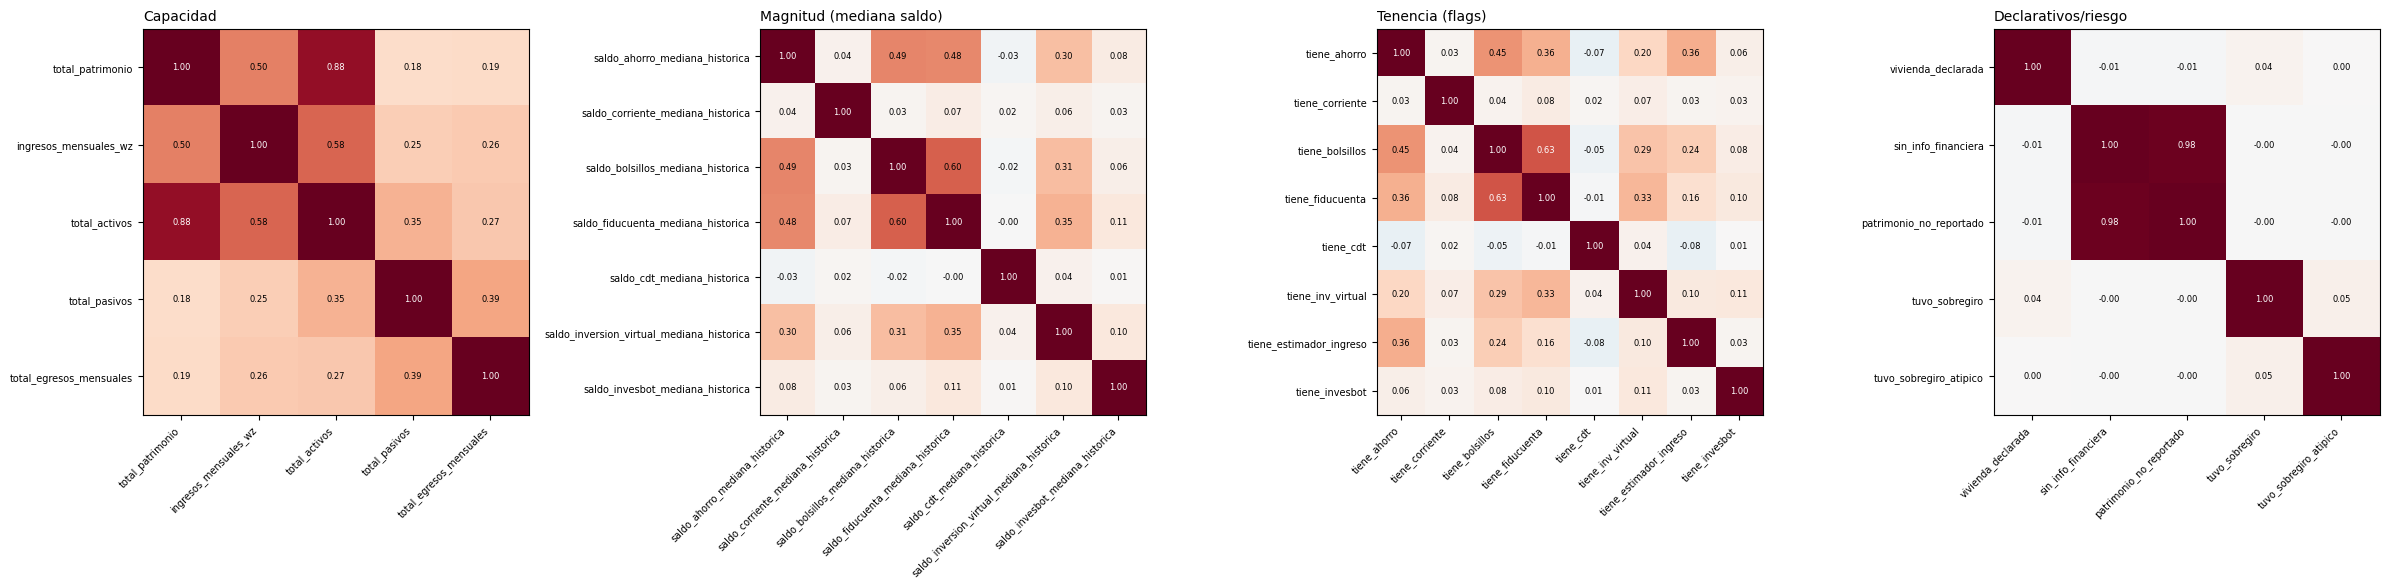

In [ ]:
bloques = {
    "Capacidad": ["total_patrimonio", "ingresos_mensuales_wz", "total_activos", "total_pasivos", "total_egresos_mensuales"],
    "Magnitud (mediana saldo)": [c for c in cols_candidatas if c.startswith("saldo_") and c.endswith("mediana_historica")],
    "Tenencia (flags)": [c for c in cols_candidatas if c.startswith("tiene_")],
    "Declarativos/riesgo": ["vivienda_declarada", "sin_info_financiera", "patrimonio_no_reportado", "tuvo_sobregiro", "tuvo_sobregiro_atipico"],
}

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
for ax, (nombre, cols) in zip(axes, bloques.items()):
    corr = df_abt_crean[cols].rank().corr()
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(cols))); ax.set_yticks(range(len(cols)))
    ax.set_xticklabels(cols, rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels(cols, fontsize=7)
    for i in range(len(cols)):
        for j in range(len(cols)):
            ax.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center", fontsize=6,
                     color="white" if abs(corr.values[i,j]) > 0.6 else "black")
    ax.set_title(nombre, fontsize=10, loc="left")
plt.tight_layout()
plt.savefig("correlacion_pool_candidatas.png", dpi=110, bbox_inches="tight")
plt.show()

### Evidencia de discriminación por producto

Para decidir qué variables entran al clustering, se midió si cada producto separa
realmente a los clientes por patrimonio — no se asumió, se calculó directamente
sobre `df_abt_crean` (860,223 filas).

### Tabla 1 — Tenencia (`tiene_X`)

| Columna | Qué mide | Fórmula |
|---|---|---|
| `prevalencia_%` | % de clientes que tienen el producto | `df[flag].mean() * 100` |
| `varianza_bernoulli` | Qué tan balanceada está la bandera (más alto = más informativa para distancia euclidiana) | `p * (1 - p)`, con `p` = prevalencia/100 |
| `gap_multiplicador` | Cuántas veces más patrimonio mediano tiene quien SÍ tiene el producto vs. quien NO | `mediana(patrimonio \| tiene=1) / mediana(patrimonio \| tiene=0)` |

**Lectura:** `corriente` tiene el gap más alto (39.7x) pero solo el 0.66% de la base
lo tiene. `fiducuenta` (10.8x) e `invesbot` (9.46x) combinan gap fuerte con
prevalencia razonable. `ahorro` es el más débil (3.08x), esperable ya que el 55%
de la base ya tiene cuenta de ahorro — "tenerla" casi no distingue a nadie.

### Tabla 2 — Magnitud (nivel de saldo)

| Columna | Qué mide | Fórmula |
|---|---|---|
| `n_holders` | Clientes que tienen el producto (denominador) | `df[flag].sum()` |
| `gap_magnitud` | Dentro de los que ya tienen el producto, ¿el NIVEL del saldo también distingue patrimonio? | `mediana(patrimonio \| saldo ≥ mediana_producto) / mediana(patrimonio \| saldo < mediana_producto)` |

**Lectura:** `ahorro` tiene el gap de magnitud más alto (10.37x), incluso mayor que
CDT (5.19x). Esto es válido y no circular: `total_patrimonio` proviene de la tabla
`clientes` (fuente independiente y declarada aparte), no se construye sumando los
saldos de bolsillos/fiducuenta/cdt/ahorro — es una relación empírica real entre dos
fuentes de datos distintas.

In [ ]:
productos = ["ahorro", "corriente", "bolsillos", "fiducuenta", "cdt", "inversion_virtual", "invesbot"]

evidencia_tenencia = []
for p in productos:
    flag = "tiene_inv_virtual" if p == "inversion_virtual" else f"tiene_{p}"
    con = df_abt_crean.loc[df_abt_crean[flag] == 1, "total_patrimonio"]
    sin = df_abt_crean.loc[df_abt_crean[flag] == 0, "total_patrimonio"]
    p_prev = df_abt_crean[flag].mean()
    evidencia_tenencia.append({
        "producto": p, "prevalencia_%": p_prev * 100,
        "varianza_bernoulli": p_prev * (1 - p_prev),
        "gap_multiplicador": con.median() / sin.median() if sin.median() > 0 else np.nan,
    })
tabla_tenencia = pd.DataFrame(evidencia_tenencia).set_index("producto").sort_values("gap_multiplicador")

evidencia_magnitud = []
for p in productos:
    col_saldo = f"saldo_{p}_mediana_historica"
    flag = "tiene_inv_virtual" if p == "inversion_virtual" else f"tiene_{p}"
    holders = df_abt_crean[df_abt_crean[flag] == 1]
    if len(holders) < 30:
        continue
    corte = holders[col_saldo].median()
    altos = holders[holders[col_saldo] >= corte]["total_patrimonio"].median()
    bajos = holders[holders[col_saldo] < corte]["total_patrimonio"].median()
    evidencia_magnitud.append({"producto": p, "n_holders": len(holders),
                                "gap_magnitud": altos / bajos if bajos > 0 else np.nan})
tabla_magnitud = pd.DataFrame(evidencia_magnitud).set_index("producto").sort_values("gap_magnitud")

print(tabla_tenencia.round(3)); print(); print(tabla_magnitud.round(3))

                   prevalencia_%  varianza_bernoulli  gap_multiplicador
producto                                                               
ahorro                    55.131               0.247              3.081
cdt                        3.054               0.030              3.411
bolsillos                 30.308               0.211              6.193
inversion_virtual          7.116               0.066              9.233
invesbot                   0.606               0.006              9.458
fiducuenta                21.043               0.166             10.794
corriente                  0.656               0.007             39.749

                   n_holders  gap_magnitud
producto                                  
corriente               5645         1.303
fiducuenta            181021         1.483
invesbot                5214         2.124
bolsillos             260714         2.170
inversion_virtual      61215         2.649
cdt                    26273         5.188
ahorro 

### Filtro de desequilibrio (umbral objetivo, no manual)

Por qué el umbral 0.02: equivale aproximadamente a exigir que la prevalencia esté entre ~2% y ~98% (p(1-p) > 0.02 se cumple para p fuera de ese rango extremo).

In [ ]:
UMBRAL_VARIANZA = 0.02  # equivalente a prevalencia fuera del rango ~2%-98%
tabla_tenencia["pasa_filtro_balance"] = tabla_tenencia["varianza_bernoulli"] > UMBRAL_VARIANZA
print(tabla_tenencia[["prevalencia_%", "varianza_bernoulli", "gap_multiplicador", "pasa_filtro_balance"]].round(3))


                   prevalencia_%  varianza_bernoulli  gap_multiplicador  \
producto                                                                  
ahorro                    55.131               0.247              3.081   
cdt                        3.054               0.030              3.411   
bolsillos                 30.308               0.211              6.193   
inversion_virtual          7.116               0.066              9.233   
invesbot                   0.606               0.006              9.458   
fiducuenta                21.043               0.166             10.794   
corriente                  0.656               0.007             39.749   

                   pasa_filtro_balance  
producto                                
ahorro                            True  
cdt                               True  
bolsillos                         True  
inversion_virtual                 True  
invesbot                         False  
fiducuenta                        Tru

### Síntesis

In [ ]:
binarias_finales = tabla_tenencia[tabla_tenencia["pasa_filtro_balance"]].index.tolist()
binarias_finales = ["tiene_" + ("inv_virtual" if p == "inversion_virtual" else p) for p in binarias_finales]
continuas_finales = ["total_patrimonio", "ingresos_mensuales_wz"] + \
    [f"saldo_{p}_mediana_historica" for p in tabla_magnitud.index]

print("Binarias:", binarias_finales)
print("Continuas:", continuas_finales)

Binarias: ['tiene_ahorro', 'tiene_cdt', 'tiene_bolsillos', 'tiene_inv_virtual', 'tiene_fiducuenta']
Continuas: ['total_patrimonio', 'ingresos_mensuales_wz', 'saldo_corriente_mediana_historica', 'saldo_fiducuenta_mediana_historica', 'saldo_invesbot_mediana_historica', 'saldo_bolsillos_mediana_historica', 'saldo_inversion_virtual_mediana_historica', 'saldo_cdt_mediana_historica', 'saldo_ahorro_mediana_historica']


### Verificación de multicolineanidad

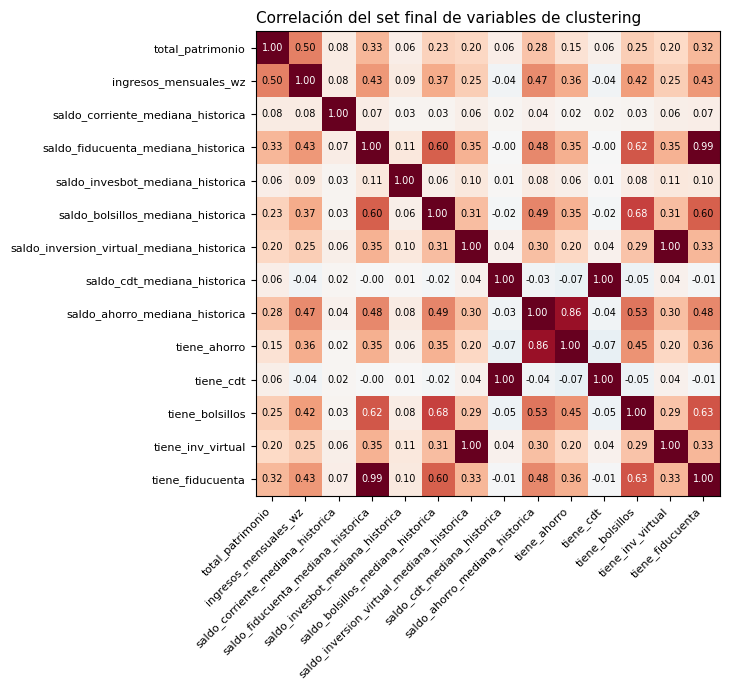

In [ ]:
cols_finales = continuas_finales + binarias_finales
corr_final = df_abt_crean[cols_finales].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_final.values, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(cols_finales))); ax.set_yticks(range(len(cols_finales)))
ax.set_xticklabels(cols_finales, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(cols_finales, fontsize=8)
for i in range(len(cols_finales)):
    for j in range(len(cols_finales)):
        ax.text(j, i, f"{corr_final.values[i,j]:.2f}", ha="center", va="center", fontsize=7,
                 color="white" if abs(corr_final.values[i,j]) > 0.6 else "black")
ax.set_title("Correlación del set final de variables de clustering", fontsize=11, loc="left")
plt.tight_layout()
plt.savefig("correlacion_set_final.png", dpi=110)
plt.show()


saldo_X_mediana_historica se rellenó con 0 para quien no tiene el producto (fillna(0)). Para productos de baja prevalencia (cdt 3%, inv_virtual 7%, fiducuenta 21%), casi toda la población tiene el mismo valor (0), y el resto tiene valores positivos. En una correlación de Spearman (basada en rangos), eso separa a la población en dos bloques de rango perfectamente ordenados — el mismo patrón exacto que dibuja la bandera binaria. El resultado: la variable "continua" termina codificando casi lo mismo que el flag, en vez de aportar la señal adicional de magnitud que buscábamos.

Para ahorro (55% prevalencia) y bolsillos (30%) el efecto es menor porque el bloque de "positivos" es mucho más grande y variado, así que la correlación con el flag no llega a ser casi perfecta.

si corr(saldo_X, tiene_X) ≥ 0.9, la magnitud ya contiene la información del flag (0 = no tiene, positivo = tiene y cuánto) — se descarta el flag, se conserva la magnitud (es la variable más rica, superset de información). Por debajo de 0.9, ambas aportan señal distinta y se conservan las dos.

In [ ]:
umbral_redundancia = 0.9
pares_flag_saldo = {
    "tiene_cdt": "saldo_cdt_mediana_historica",
    "tiene_inv_virtual": "saldo_inversion_virtual_mediana_historica",
    "tiene_fiducuenta": "saldo_fiducuenta_mediana_historica",
    "tiene_ahorro": "saldo_ahorro_mediana_historica",
    "tiene_bolsillos": "saldo_bolsillos_mediana_historica",
}

binarias_finales = [
    flag for flag, saldo in pares_flag_saldo.items()
    if corr_final.loc[flag, saldo] < umbral_redundancia
]
print("Binarias finales:", binarias_finales)

Binarias finales: ['tiene_ahorro', 'tiene_bolsillos']


## Log-transform + StandardScaler sobre las 11 variables finales

Para cada columna, resta la media y divide por la desviación estándar:

$$z = \frac{x - \mu}{\sigma}$$

El resultado: todas las variables quedan en la misma escala (media 0, varianza 1), sin importar si originalmente estaban en pesos (millones), porcentajes o unidades. Esto es obligatorio antes de K-means porque el algoritmo mide distancia euclidiana entre puntos — sin escalar, total_patrimonio (valores en millones) dominaría completamente la distancia frente a variables como tiene_ahorro (0 o 1), y el clustering terminaría agrupando solo por patrimonio, ignorando el resto de variables aunque tengan poder de discriminación real (ya demostrado en las tablas de evidencia).

Las binarias no se escalan: ya están en un rango comparable (0/1)

### Winsorización

Se recorta al percentil 99 el patrimonio y los saldos por producto, para que
unos pocos valores extremos no distorsionen la distancia euclidiana de
K-means. El percentil se calcula **solo entre quienes tienen el producto**,
no sobre toda la población: para productos de baja prevalencia, el percentil
99 de la población completa cae en cero y borraría toda la señal real.

In [ ]:
cols_producto = [
    "saldo_corriente_mediana_historica", "saldo_fiducuenta_mediana_historica",
    "saldo_invesbot_mediana_historica", "saldo_bolsillos_mediana_historica",
    "saldo_inversion_virtual_mediana_historica", "saldo_cdt_mediana_historica",
    "saldo_ahorro_mediana_historica",
]

for col in cols_producto:
    holders = df_abt_crean[col] > 0
    p99_holders = df_abt_crean.loc[holders, col].quantile(0.99)
    n_afectados = (df_abt_crean[col] > p99_holders).sum()
    print(f"{col}: p99(solo holders)={p99_holders:,.0f}, clientes afectados={n_afectados}")
    df_abt_crean[col + "_wz"] = df_abt_crean[col].clip(upper=p99_holders)

p99_patrimonio = df_abt_crean["total_patrimonio"].quantile(0.99)
df_abt_crean["total_patrimonio_wz"] = df_abt_crean["total_patrimonio"].clip(upper=p99_patrimonio)

saldo_corriente_mediana_historica: p99(solo holders)=118,922,058, clientes afectados=49
saldo_fiducuenta_mediana_historica: p99(solo holders)=124,563,427, clientes afectados=1811
saldo_invesbot_mediana_historica: p99(solo holders)=209,492,436, clientes afectados=53
saldo_bolsillos_mediana_historica: p99(solo holders)=26,000,000, clientes afectados=1466
saldo_inversion_virtual_mediana_historica: p99(solo holders)=310,000,000, clientes afectados=604
saldo_cdt_mediana_historica: p99(solo holders)=400,000,000, clientes afectados=250
saldo_ahorro_mediana_historica: p99(solo holders)=65,562,340, clientes afectados=4463


In [ ]:
cols_wz = [c for c in df_abt_crean.columns if c.endswith("_wz") and c != "ingresos_mensuales_wz"]
df_abt_crean[cols_wz].describe().T[["min", "50%", "max"]]

,min,50%,max
estimador_ingreso_wz,6.705850e+04,2322294.50,2.264586e+07
saldo_corriente_mediana_historica_wz,-1.739092e+07,0.00,1.189221e+08
saldo_fiducuenta_mediana_historica_wz,0.000000e+00,0.00,1.245634e+08
saldo_invesbot_mediana_historica_wz,0.000000e+00,0.00,2.094924e+08
saldo_bolsillos_mediana_historica_wz,0.000000e+00,0.00,2.600000e+07
saldo_inversion_virtual_mediana_historica_wz,0.000000e+00,0.00,3.100000e+08
saldo_cdt_mediana_historica_wz,0.000000e+00,0.00,4.000000e+08
saldo_ahorro_mediana_historica_wz,-1.455620e+03,209.52,6.556234e+07
total_patrimonio_wz,-3.494437e+11,7000000.00,6.750000e+08


In [ ]:
cols_revisar = ["total_patrimonio_wz", "saldo_corriente_mediana_historica_wz", "saldo_ahorro_mediana_historica_wz"]

for col in cols_revisar:
    n_neg = (df_abt_crean[col] < 0).sum()
    print(f"{col}: {n_neg} clientes negativos ({n_neg/len(df_abt_crean)*100:.4f}%)")

mask_patrimonio_neg = df_abt_crean["total_patrimonio_wz"] < 0
print(df_abt_crean.loc[mask_patrimonio_neg, ["sin_info_financiera", "patrimonio_no_reportado"]].mean())

total_patrimonio_wz: 6165 clientes negativos (0.7167%)
saldo_corriente_mediana_historica_wz: 667 clientes negativos (0.0775%)
saldo_ahorro_mediana_historica_wz: 1 clientes negativos (0.0001%)
sin_info_financiera        0.0
patrimonio_no_reportado    0.0
dtype: float64


In [ ]:
n_cero = (df_abt_crean["ingresos_mensuales_wz"] == 0).sum()
print(f"{n_cero} clientes ({n_cero/len(df_abt_crean)*100:.3f}%) con ingreso = 0")
print(df_abt_crean.loc[df_abt_crean["ingresos_mensuales_wz"] == 0, "sin_info_financiera"].mean())
print(df_abt_crean.loc[df_abt_crean["ingresos_mensuales_wz"] == 0, "total_patrimonio_wz"].describe())

9296 clientes (1.081%) con ingreso = 0
0.0
count    9.296000e+03
mean     5.321694e+06
std      4.161483e+07
min     -5.883066e+08
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      6.750000e+08
Name: total_patrimonio_wz, dtype: float64


In [ ]:
negativos = df_abt_crean.loc[df_abt_crean["total_patrimonio_wz"] < 0, "total_patrimonio_wz"]
print(negativos.describe())
print(negativos.quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

count    6.165000e+03
mean    -2.380423e+08
std      7.129086e+09
min     -3.494437e+11
25%     -2.500000e+07
50%     -3.455000e+06
75%     -6.500000e+05
max     -1.000000e+00
Name: total_patrimonio_wz, dtype: float64
0.01   -510102400.0
0.05    -75991800.0
0.25    -25000000.0
0.50     -3455000.0
0.75      -650000.0
0.95      -100000.0
0.99       -10000.0
Name: total_patrimonio_wz, dtype: float64


In [ ]:
cols_piso_cero = [
    "total_patrimonio_wz",
    "saldo_corriente_mediana_historica_wz",
    "saldo_ahorro_mediana_historica_wz",
]

for col in cols_piso_cero:
    n_neg = (df_abt_crean[col] < 0).sum()
    print(f"{col}: {n_neg} clientes negativos ({n_neg/len(df_abt_crean)*100:.4f}%) -> piso en 0")
    df_abt_crean[col] = df_abt_crean[col].clip(lower=0)

total_patrimonio_wz: 6165 clientes negativos (0.7167%) -> piso en 0
saldo_corriente_mediana_historica_wz: 667 clientes negativos (0.0775%) -> piso en 0
saldo_ahorro_mediana_historica_wz: 1 clientes negativos (0.0001%) -> piso en 0


## Clustering - KMeans

In [ ]:
continuas_finales = [
    "total_patrimonio_wz", "ingresos_mensuales_wz",
    "saldo_fiducuenta_mediana_historica_wz", "saldo_bolsillos_mediana_historica_wz",
    "saldo_inversion_virtual_mediana_historica_wz", "saldo_cdt_mediana_historica_wz",
    "saldo_ahorro_mediana_historica_wz",
]

X_continuas_log = np.log1p(df_abt_crean[continuas_finales].clip(lower=0))
X_continuas_scaled = StandardScaler().fit_transform(X_continuas_log)
X_final = np.hstack([X_continuas_scaled, df_abt_crean[binarias_finales].values])

rng = np.random.default_rng(42)
idx_muestra = rng.choice(X_final.shape[0], size=50000, replace=False)
X_muestra = X_final[idx_muestra]

### Método del codo y silhouette  

**Por qué hay que buscar k, y qué es silhouette**

K-means necesita de antemano en cuántos grupos dividir los
datos — a diferencia de otros algoritmos, no lo descubre solo. Si se elige mal
k, termina con clusters que no reflejan nada real: muy pocos, y mezclas
comportamientos distintos en un solo grupo; muchos, y divides un mismo
comportamiento en pedazos artificiales sin significado de negocio.

Se usan dos métricas juntas porque cada una, sola, engaña:

- **Inercia (método del codo):** suma de qué tan lejos está cada cliente del
  centro de su cluster. Siempre baja al aumentar k, incluso cuando ya no hay
  estructura real que separar — por eso se busca el punto donde la caída deja
  de ser pronunciada (el "codo"), no el valor más bajo posible.
- **Silhouette score:** para cada cliente, compara qué tan cerca está de su
  propio cluster frente a qué tan cerca está del cluster más próximo. Va de
  -1 a 1: valores altos significan clusters compactos y bien separados;
  valores cerca de 0 significan clusters que se solapan. A diferencia de la
  inercia, sí penaliza tener demasiados clusters, así que sirve para
  contrastar lo que sugiere el codo.

El k elegido es donde ambas señales coinciden — el codo de la inercia y un
silhouette alto — combinado con un criterio de negocio: entre 4 y 8 clusters
suele ser el rango manejable para explicar y accionar en una presentación,
incluso si estadísticamente un k mayor diera un silhouette marginalmente
mejor.


In [ ]:
resultados = []
for k in range(2, 16):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = modelo.fit_predict(X_muestra)
    tamanos = pd.Series(labels).value_counts(normalize=True) * 100
    resultados.append({
        "k": k,
        "inertia": modelo.inertia_,
        "silhouette": silhouette_score(X_muestra, labels, sample_size=10000, random_state=42),
        "cluster_mas_pequeno_%": tamanos.min(),
        "cluster_mas_grande_%": tamanos.max(),
    })

tabla_k = pd.DataFrame(resultados)
print(tabla_k.round(3))


     k     inertia  silhouette  cluster_mas_pequeno_%  cluster_mas_grande_%
0    2  266798.198       0.410                 23.634                76.366
1    3  220736.374       0.436                  3.040                73.952
2    4  179753.212       0.394                  3.040                55.876
3    5  145198.356       0.427                  3.040                54.516
4    6  110856.732       0.433                  1.256                54.506
5    7   83949.223       0.481                  1.256                32.642
6    8   71921.737       0.500                  1.256                31.610
7    9   65061.946       0.508                  1.256                31.464
8   10   58301.984       0.514                  1.256                31.458
9   11   52581.936       0.527                  1.256                31.400
10  12   48149.427       0.529                  0.626                31.400
11  13   45869.877       0.529                  0.626                31.400
12  14   433

In [ ]:
for k in [7, 8]:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=20).fit(X_muestra)
    labels = modelo.labels_
    perfil = pd.DataFrame(X_muestra, columns=continuas_finales + binarias_finales)
    perfil["cluster"] = labels
    print(f"\n=== k={k} ===")
    print(perfil.groupby("cluster").mean().round(2))
    print(pd.Series(labels).value_counts(normalize=True).sort_index().round(3) * 100)



=== k=7 ===
         total_patrimonio_wz  ingresos_mensuales_wz  \
cluster                                               
0                       0.56                   0.51   
1                       0.42                  -0.03   
2                       0.43                   0.17   
3                       0.50                   0.46   
4                       0.27                   0.05   
5                      -1.56                  -7.81   
6                      -1.89                  -0.15   

         saldo_fiducuenta_mediana_historica_wz  \
cluster                                          
0                                         1.25   
1                                        -0.40   
2                                        -0.23   
3                                         1.42   
4                                         0.03   
5                                        -0.45   
6                                        -0.45   

         saldo_bolsillos_mediana_histori

**Por qué saldo_corriente y saldo_invesbot NO entran en la distancia final**

Durante la búsqueda de k, un cluster de tamaño fijo (~0.57%-0.60%) apareció en
casi todos los valores de k probados, sin importar la winsorización aplicada.
Al perfilar ese cluster, `saldo_corriente_mediana_historica_wz` mostró una
diferencia de 13.3 desviaciones estándar frente al resto — muy por encima de
cualquier otra variable. Al excluirla, el mismo síntoma reapareció con
`saldo_invesbot_mediana_historica_wz` (diferencia de 12.8 SD).

Causa raíz: ambos productos tienen prevalencia extrema (corriente 0.66%,
invesbot 0.61%). Aunque están winsorizados, más del 99% de la población tiene
valor 0 en esa columna — la FORMA de la distribución (no su escala) sigue
generando una separación artificial en K-means. Es el mismo criterio de
varianza de Bernoulli aplicado a las binarias, extendido a estas dos continuas.

Ambas variables se conservan en `df_abt_crean` para perfilar los clusters
después — quedan fuera solo de la distancia.


### Validación de robustez del modelo

#### Estabilidad de k entre muestras
La búsqueda de k se hizo sobre una sola muestra de 50,000 clientes. Se repite
con 5 muestras y semillas distintas para confirmar que k=8 no es un accidente
de esa muestra en particular.


seed     1      7      21     42     99
k                                      
5     0.361  0.428  0.365  0.427  0.424
6     0.396  0.435  0.399  0.391  0.437
7     0.486  0.482  0.488  0.481  0.479
8     0.503  0.500  0.505  0.500  0.500
9     0.508  0.506  0.511  0.508  0.508
10    0.517  0.515  0.526  0.514  0.514


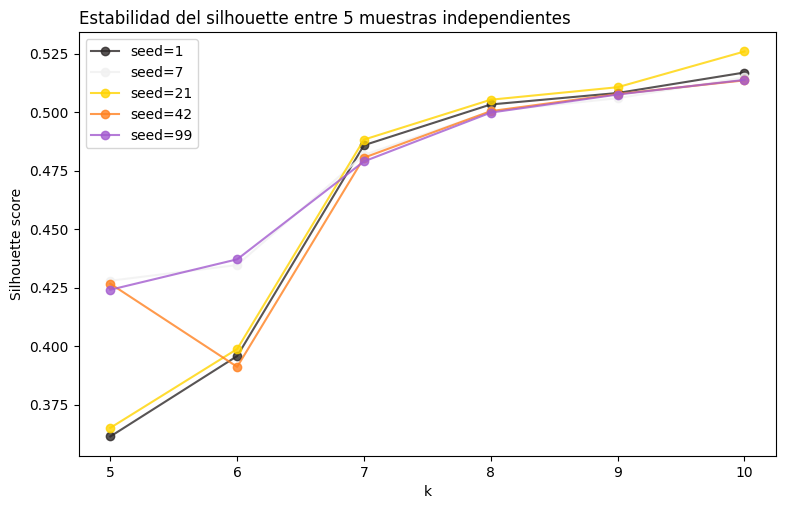

In [ ]:
resultados_estabilidad = []
for seed in [1, 7, 21, 42, 99]:
    rng_i = np.random.default_rng(seed)
    idx_i = rng_i.choice(X_final.shape[0], size=50000, replace=False)
    X_i = X_final[idx_i]
    for k in range(5, 11):
        modelo = KMeans(n_clusters=k, random_state=seed, n_init=10)
        labels = modelo.fit_predict(X_i)
        sil = silhouette_score(X_i, labels, sample_size=10000, random_state=seed)
        resultados_estabilidad.append({"seed": seed, "k": k, "silhouette": sil})

tabla_estabilidad = pd.DataFrame(resultados_estabilidad)
pivot = tabla_estabilidad.pivot(index="k", columns="seed", values="silhouette")
print(pivot.round(3))

fig, ax = plt.subplots(figsize=(9, 5.5))
colores_paleta = list(PALETA.values())
for i, seed in enumerate(pivot.columns):
    ax.plot(pivot.index, pivot[seed], marker="o", label=f"seed={seed}", alpha=0.8, color=colores_paleta[i % len(colores_paleta)])
ax.set_xlabel("k"); ax.set_ylabel("Silhouette score")
ax.set_title("Estabilidad del silhouette entre 5 muestras independientes", fontsize=12, loc="left")
ax.legend()
plt.savefig("estabilidad_k.png", dpi=110)
plt.show()

#### ¿El supuesto esférico de K-means distorsiona los clusters?
K-means asume grupos de forma esférica y varianza similar, un supuesto que
rara vez se cumple del todo en datos financieros. Se compara contra un
Gaussian Mixture Model (que no asume esferas) con el Adjusted Rand Index: si
ambos coinciden con un (>0.60-0.70), la estructura encontrada es real, no un artefacto del
supuesto de K-means.


In [ ]:
modelo_kmeans = KMeans(n_clusters=8, random_state=42, n_init=20).fit(X_muestra)
labels_kmeans = modelo_kmeans.labels_

modelo_gmm = GaussianMixture(n_components=8, random_state=42, n_init=5).fit(X_muestra)
labels_gmm = modelo_gmm.predict(X_muestra)

ari = adjusted_rand_score(labels_kmeans, labels_gmm)
print(f"Adjusted Rand Index (K-means vs GMM): {ari:.3f}")

perfil_var = pd.DataFrame(X_muestra, columns=continuas_finales + binarias_finales)
perfil_var["cluster"] = labels_kmeans
print(perfil_var.groupby("cluster").std().round(2))

Adjusted Rand Index (K-means vs GMM): 0.627
         total_patrimonio_wz  ingresos_mensuales_wz  \
cluster                                               
0                       0.35                   0.37   
1                       0.58                   0.37   
2                       0.37                   0.37   
3                       0.73                   0.21   
4                       0.91                   0.48   
5                       0.09                   0.34   
6                       0.56                   0.41   
7                       0.43                   0.43   

         saldo_fiducuenta_mediana_historica_wz  \
cluster                                          
0                                         0.08   
1                                         1.17   
2                                         0.20   
3                                         0.32   
4                                         1.12   
5                                         0.23   
6    

#### Perfilado de corriente e invesbot por cluster
Se excluyeron de la distancia por su prevalencia extrema, pero no se pierden:
aquí se usan para perfilar los clusters ya formados y confirmar si el
segmento que el modelo encontró de forma independiente coincide con los
adoptantes reales de invesbot.


In [ ]:
df_muestra_perfil = df_abt_crean.iloc[idx_muestra].copy()
df_muestra_perfil["cluster"] = labels_kmeans

base_invesbot = df_abt_crean["tiene_invesbot"].mean() * 100
base_corriente = df_abt_crean["tiene_corriente"].mean() * 100

perfil_reservadas = df_muestra_perfil.groupby("cluster")[["tiene_corriente", "tiene_invesbot"]].mean() * 100
perfil_reservadas["lift_invesbot"] = perfil_reservadas["tiene_invesbot"] / base_invesbot
perfil_reservadas["lift_corriente"] = perfil_reservadas["tiene_corriente"] / base_corriente
print(perfil_reservadas.round(2))

         tiene_corriente  tiene_invesbot  lift_invesbot  lift_corriente
cluster                                                                
0                   0.46            0.14           0.23            0.70
1                   1.12            1.17           1.93            1.71
2                   0.37            0.03           0.04            0.56
3                   0.00            0.16           0.26            0.00
4                   1.92            1.06           1.75            2.92
5                   0.01            0.03           0.06            0.02
6                   2.19            3.32           5.48            3.34
7                   2.09            2.69           4.44            3.19


#### ¿Los clusters son solo niveles de patrimonio?
Varias variables se eligieron por su correlación con patrimonio, así que
existe el riesgo de que los clusters sean solo niveles de riqueza con otro
nombre. η² mide qué proporción de la varianza de cada variable explica la
pertenencia a un cluster — si solo patrimonio tiene η² alto, se confirma el
riesgo; si las variables de producto también aportan, los clusters sí
capturan comportamiento, no solo dinero.


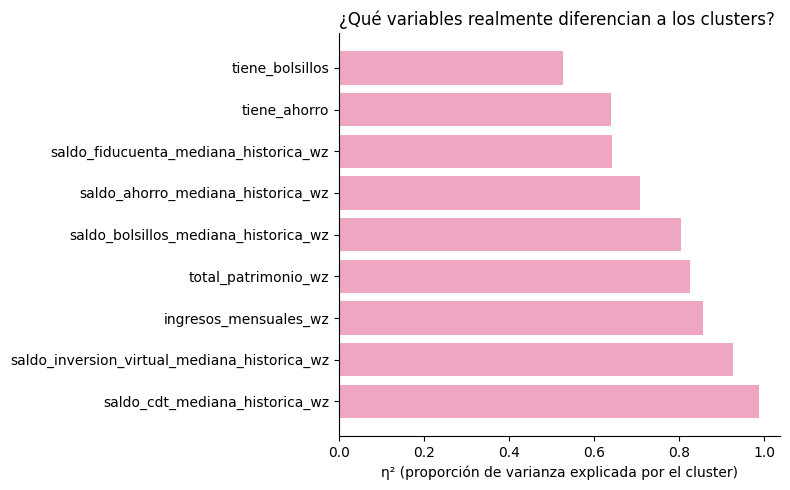

saldo_cdt_mediana_historica_wz                  0.988
saldo_inversion_virtual_mediana_historica_wz    0.926
ingresos_mensuales_wz                           0.855
total_patrimonio_wz                             0.825
saldo_bolsillos_mediana_historica_wz            0.803
saldo_ahorro_mediana_historica_wz               0.709
saldo_fiducuenta_mediana_historica_wz           0.641
tiene_ahorro                                    0.641
tiene_bolsillos                                 0.526
dtype: float64


In [ ]:
def eta_cuadrado(df, cluster_col, valor_col):
    media_global = df[valor_col].mean()
    ss_total = ((df[valor_col] - media_global) ** 2).sum()
    ss_between = df.groupby(cluster_col)[valor_col].apply(
        lambda g: len(g) * (g.mean() - media_global) ** 2
    ).sum()
    return ss_between / ss_total

perfil_eta = pd.DataFrame(X_muestra, columns=continuas_finales + binarias_finales)
perfil_eta["cluster"] = labels_kmeans

tabla_eta = pd.Series({col: eta_cuadrado(perfil_eta, "cluster", col) for col in continuas_finales + binarias_finales})
tabla_eta = tabla_eta.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(tabla_eta.index, tabla_eta.values, color=PALETA['rosa'])
ax.set_xlabel("η² (proporción de varianza explicada por el cluster)")
ax.set_title("¿Qué variables realmente diferencian a los clusters?", fontsize=12, loc="left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("eta_cuadrado_clusters.png", dpi=110)
plt.show()
print(tabla_eta.round(3))


Esta gráfica identifica cuáles características realmente marcan la diferencia entre los grupos de clientes que se formaron en el análisis de segmentación. El saldo de CDT es la variable que mejor separa a los clusters, seguida de la inversión virtual, los ingresos mensuales y el patrimonio total, lo que indica que los grupos se diferencian sobre todo por su nivel de recursos económicos y por el uso de productos de inversión más sofisticados. En otras palabras, la segmentación está capturando principalmente diferencias de poder adquisitivo y de comportamiento inversionista entre los clientes.

En el otro extremo, el simple hecho de tener bolsillos o tener ahorro es lo que menos distingue a un grupo de otro, lo cual tiene sentido porque son productos tan comunes que casi todos los clientes los poseen, sin importar a qué grupo pertenezcan. Esto confirma que los clusters no se están formando por la posesión básica de productos, sino por los montos que cada cliente maneja, especialmente en productos de mayor nivel financiero como CDT e inversión virtual.

#### Visualización de clusters (PCA)
Proyección a 2 dimensiones solo para graficar el resultado — el modelo sigue
usando las 9 variables completas, esta vista es apoyo visual, no parte del
clustering.


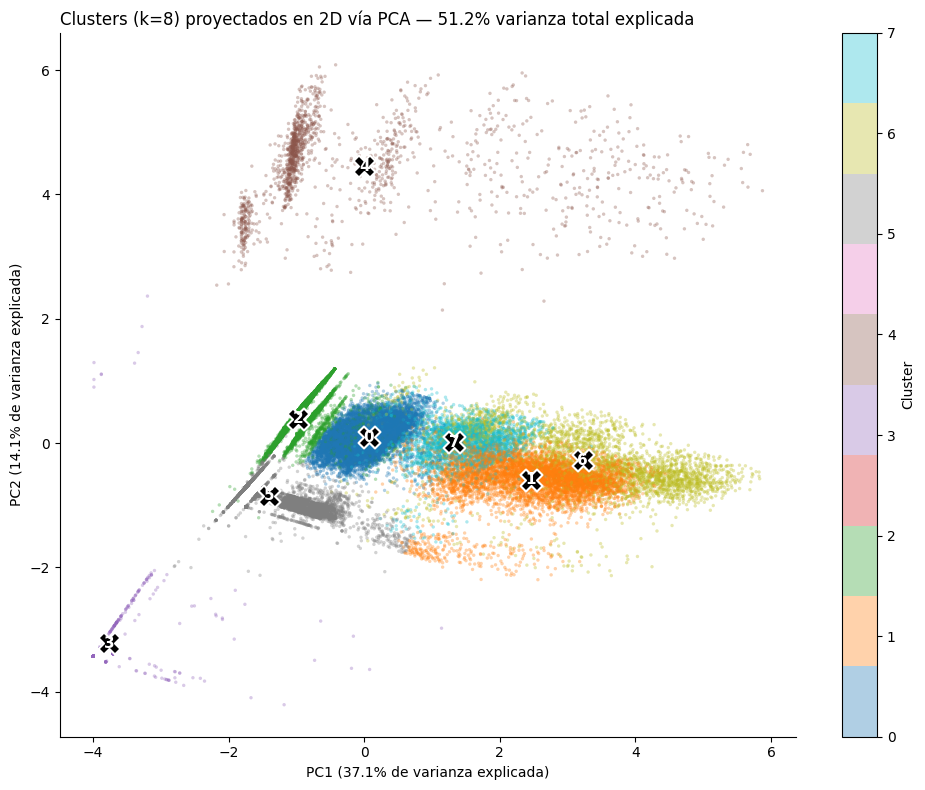

In [ ]:
modelo_k8 = KMeans(n_clusters=8, random_state=42, n_init=20).fit(X_muestra)
labels_k8 = modelo_k8.labels_

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_muestra)
centroides_pca = pca.transform(modelo_k8.cluster_centers_)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_k8, cmap="tab10",
                      s=6, alpha=0.35, linewidths=0)
ax.scatter(centroides_pca[:, 0], centroides_pca[:, 1], c="black", marker="X",
           s=250, edgecolors="white", linewidths=1.5, label="Centroides", zorder=5)

for i, (x, y) in enumerate(centroides_pca):
    ax.annotate(str(i), (x, y), fontsize=11, fontweight="bold",
                ha="center", va="center", color="white", zorder=6)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% de varianza explicada)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% de varianza explicada)")
ax.set_title(f"Clusters (k=8) proyectados en 2D vía PCA — {pca.explained_variance_ratio_.sum()*100:.1f}% varianza total explicada",
             fontsize=12, loc="left")
ax.spines[["top", "right"]].set_visible(False)
plt.colorbar(scatter, label="Cluster", ticks=range(8))
plt.tight_layout()
plt.savefig("clusters_pca.png", dpi=110)
plt.show()


#### Modelo final sobre las 860,223 filas
Todo lo anterior se validó sobre una muestra de 50,000 clientes. Aquí se
entrena el modelo definitivo sobre la población completa y se compara contra
la muestra — alineando los clusters por centroide, porque K-means no
garantiza que el mismo número de cluster represente al mismo grupo entre
corridas distintas.


In [ ]:
modelo_final = KMeans(n_clusters=8, random_state=42, n_init=20)
labels_full = modelo_final.fit_predict(X_final)
df_abt_crean["cluster"] = labels_full

print(df_abt_crean["cluster"].value_counts(normalize=True).sort_index().round(3) * 100)

cluster
0    17.7
1    21.6
2    31.7
3     6.6
4    12.0
5     1.3
6     3.0
7     6.0
Name: proportion, dtype: float64


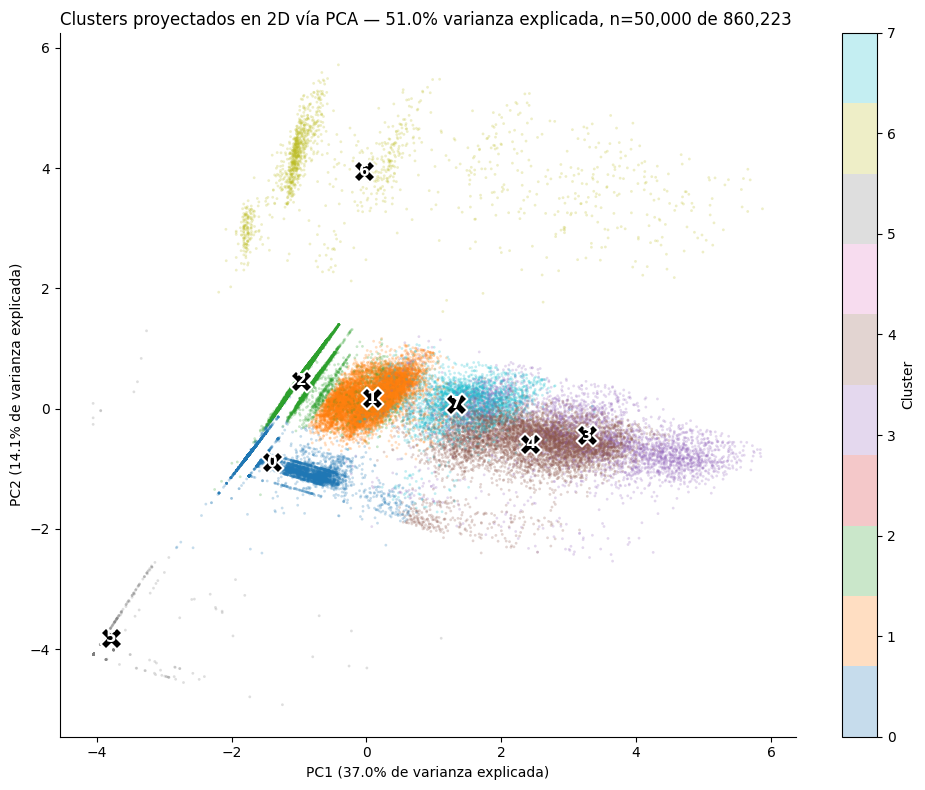

In [ ]:
from sklearn.decomposition import PCA

def graficar_clusters_pca(X, labels, centros, n_muestra_plot=50000,
                           titulo="Clusters proyectados en 2D vía PCA"):
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X)
    centroides_pca = pca.transform(centros)

    rng_plot = np.random.default_rng(42)
    idx_plot = rng_plot.choice(X.shape[0], size=min(n_muestra_plot, X.shape[0]), replace=False)

    fig, ax = plt.subplots(figsize=(10, 8))
    scatter = ax.scatter(X_pca[idx_plot, 0], X_pca[idx_plot, 1], c=labels[idx_plot],
                          cmap="tab10", s=4, alpha=0.25, linewidths=0)
    ax.scatter(centroides_pca[:, 0], centroides_pca[:, 1], c="black", marker="X",
               s=250, edgecolors="white", linewidths=1.5, label="Centroides", zorder=5)
    for i, (x, y) in enumerate(centroides_pca):
        ax.annotate(str(i), (x, y), fontsize=11, fontweight="bold",
                    ha="center", va="center", color="white", zorder=6)

    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% de varianza explicada)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% de varianza explicada)")
    ax.set_title(
        f"{titulo} — {pca.explained_variance_ratio_.sum()*100:.1f}% varianza explicada, "
        f"n={len(idx_plot):,} de {X.shape[0]:,}",
        fontsize=12, loc="left"
    )
    ax.spines[["top", "right"]].set_visible(False)
    plt.colorbar(scatter, label="Cluster", ticks=range(len(centros)))
    plt.tight_layout()
    plt.savefig("clusters_pca_poblacion_completa.png", dpi=110)
    plt.show()

graficar_clusters_pca(X_final, labels_full, modelo_final.cluster_centers_)

In [ ]:
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

centroides_muestra = modelo_kmeans.cluster_centers_
centroides_full = modelo_final.cluster_centers_

distancias = cdist(centroides_muestra, centroides_full)
fila_ind, col_ind = linear_sum_assignment(distancias)
mapeo = dict(zip(fila_ind, col_ind))
print("Mapeo cluster (muestra -> completo):", mapeo)

# Calculate cluster proportions for sample and full data
prop_muestra = pd.Series(labels_kmeans).value_counts(normalize=True).sort_index() * 100
prop_full = pd.Series(labels_full).value_counts(normalize=True).sort_index() * 100

prop_muestra_alineada = prop_muestra.rename(index=mapeo).sort_index()
comparacion_alineada = pd.DataFrame({
    "muestra_50k_%": prop_muestra_alineada,
    "poblacion_completa_%": prop_full.sort_index(),
})
comparacion_alineada["diferencia_pp"] = (
    comparacion_alineada["poblacion_completa_%"] - comparacion_alineada["muestra_50k_%"]
)
print(comparacion_alineada.round(2))

Mapeo cluster (muestra -> completo): {np.int64(0): np.int64(1), np.int64(1): np.int64(4), np.int64(2): np.int64(2), np.int64(3): np.int64(5), np.int64(4): np.int64(6), np.int64(5): np.int64(0), np.int64(6): np.int64(3), np.int64(7): np.int64(7)}
   muestra_50k_%  poblacion_completa_%  diferencia_pp
0          17.61                 17.71           0.10
1          21.78                 21.62          -0.16
2          31.61                 31.69           0.08
3           6.56                  6.64           0.08
4          12.14                 12.03          -0.11
5           1.26                  1.32           0.07
6           3.02                  3.02           0.00
7           6.02                  5.96          -0.06


#### Evaluación de calidad del modelo de clustering

##### Hopkins statistic
Compara la distancia entre puntos reales con la distancia que tendrían puntos generados al azar (uniformes) en el mismo espacio. Valor cercano a 1 = los datos sí tienen tendencia real a agruparse.

In [ ]:
from sklearn.neighbors import NearestNeighbors

def hopkins_statistic(X, n_muestra=500, random_state=42):
    rng = np.random.default_rng(random_state)
    n, d = X.shape
    idx_muestra = rng.choice(n, size=n_muestra, replace=False)
    X_muestra_real = X[idx_muestra]

    minimos, maximos = X.min(axis=0), X.max(axis=0)
    X_uniforme = rng.uniform(minimos, maximos, size=(n_muestra, d))

    nn = NearestNeighbors(n_neighbors=2).fit(X)
    dist_real, _ = nn.kneighbors(X_muestra_real)
    u_real = dist_real[:, 1].sum()

    dist_uniforme, _ = nn.kneighbors(X_uniforme)
    u_uniforme = dist_uniforme[:, 0].sum()

    return u_uniforme / (u_uniforme + u_real)

h = hopkins_statistic(X_muestra)
print(f"Hopkins statistic: {h:.3f}")


Hopkins statistic: 0.980


##### Comparar K-means contra una partición aleatoria del mismo tamaño

*   **Calinski-Harabasz:** sirve para saber si tus clusters están bien separados y compactos — más alto es mejor. Se usa sobre todo para comparar entre distintos k, no como número aislado.
*   **Davies-Bouldin:** sirve para saber qué tanto se solapan tus clusters entre sí — más bajo es mejor, y a diferencia del anterior, sí se puede leer solo (por debajo de 1 es razonable).

In [ ]:
rng = np.random.default_rng(42)
labels_aleatorias = labels_kmeans.copy()
rng.shuffle(labels_aleatorias)

def resumen_metricas(X, labels, nombre):
    sil = silhouette_score(X, labels, sample_size=10000, random_state=42)
    ch = calinski_harabasz_score(X, labels)
    db = davies_bouldin_score(X, labels)
    print(f"{nombre:25s} silhouette={sil:.3f}  CH={ch:,.1f}  DB={db:.3f}")

resumen_metricas(X_muestra, labels_kmeans, "K-means (real)")
resumen_metricas(X_muestra, labels_aleatorias, "Partición aleatoria")

K-means (real)            silhouette=0.500  CH=29,683.5  DB=0.737
Partición aleatoria       silhouette=-0.019  CH=0.7  DB=151.197


La partición aleatoria se desempeña prácticamente como ruido puro en las tres métricas — silhouette casi en 0 (-0.019, sin separación real), Calinski-Harabasz casi en 0 (0.7, sin estructura), y Davies-Bouldin disparado a 151 (clusters completamente solapados, muy por encima del umbral de "razonable" que es <1). Tu modelo real, en cambio, tiene silhouette 0.5, CH de casi 30,000, y DB de 0.737 — una diferencia de varios órdenes de magnitud en las tres métricas al mismo tiempo.

Qué prueba: que K-means no está "inventando" grupos porque las métricas tienden a verse bien con cualquier partición en datos de alta dimensión — está capturando estructura genuina en el comportamiento financiero de los clientes. Si no fuera así, la partición aleatoria se vería casi igual de "buena" que la real, y claramente no es el caso.

Para tu defensa: esta es tu respuesta directa a "¿cómo sabes que el modelo no solo está dividiendo datos al azar?" — la comparación numérica lo demuestra sin ambigüedad, no como algo que dices sino como algo que mides.

## Interpretación del comportamiento de los datos de cada clúster

In [ ]:
cols_perfil_numericas = [
    "total_patrimonio_wz", "ingresos_mensuales_wz",
    "saldo_fiducuenta_mediana_historica_wz", "saldo_bolsillos_mediana_historica_wz",
    "saldo_inversion_virtual_mediana_historica_wz", "saldo_cdt_mediana_historica_wz",
    "saldo_ahorro_mediana_historica_wz", "saldo_corriente_mediana_historica_wz",
    "saldo_invesbot_mediana_historica_wz",
]
cols_perfil_binarias = ["tiene_ahorro", "tiene_bolsillos", "tiene_fiducuenta",
                         "tiene_cdt", "tiene_inv_virtual", "tiene_corriente", "tiene_invesbot"]

tamano_cluster = df_abt_crean["cluster"].value_counts(normalize=True).sort_index() * 100
perfil_numerico = df_abt_crean.groupby("cluster")[cols_perfil_numericas].median()
perfil_binario = df_abt_crean.groupby("cluster")[cols_perfil_binarias].mean() * 100

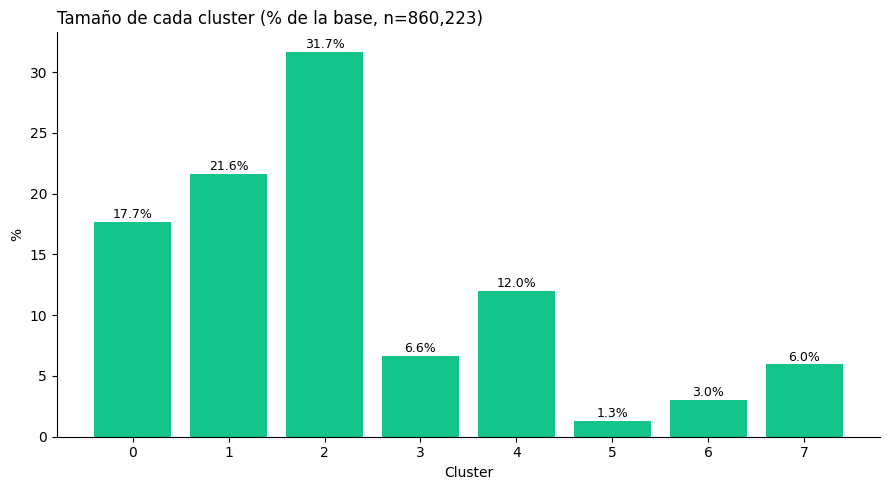

In [ ]:
# ---------- Gráfica 1: tamaño de cada cluster ----------
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(tamano_cluster.index.astype(str), tamano_cluster.values, color=PALETA['verde'])
for bar, v in zip(bars, tamano_cluster.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)
ax.set_title("Tamaño de cada cluster (% de la base, n=860,223)", fontsize=12, loc="left")
ax.set_xlabel("Cluster"); ax.set_ylabel("%")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("tamano_clusters.png", dpi=110)
plt.show()

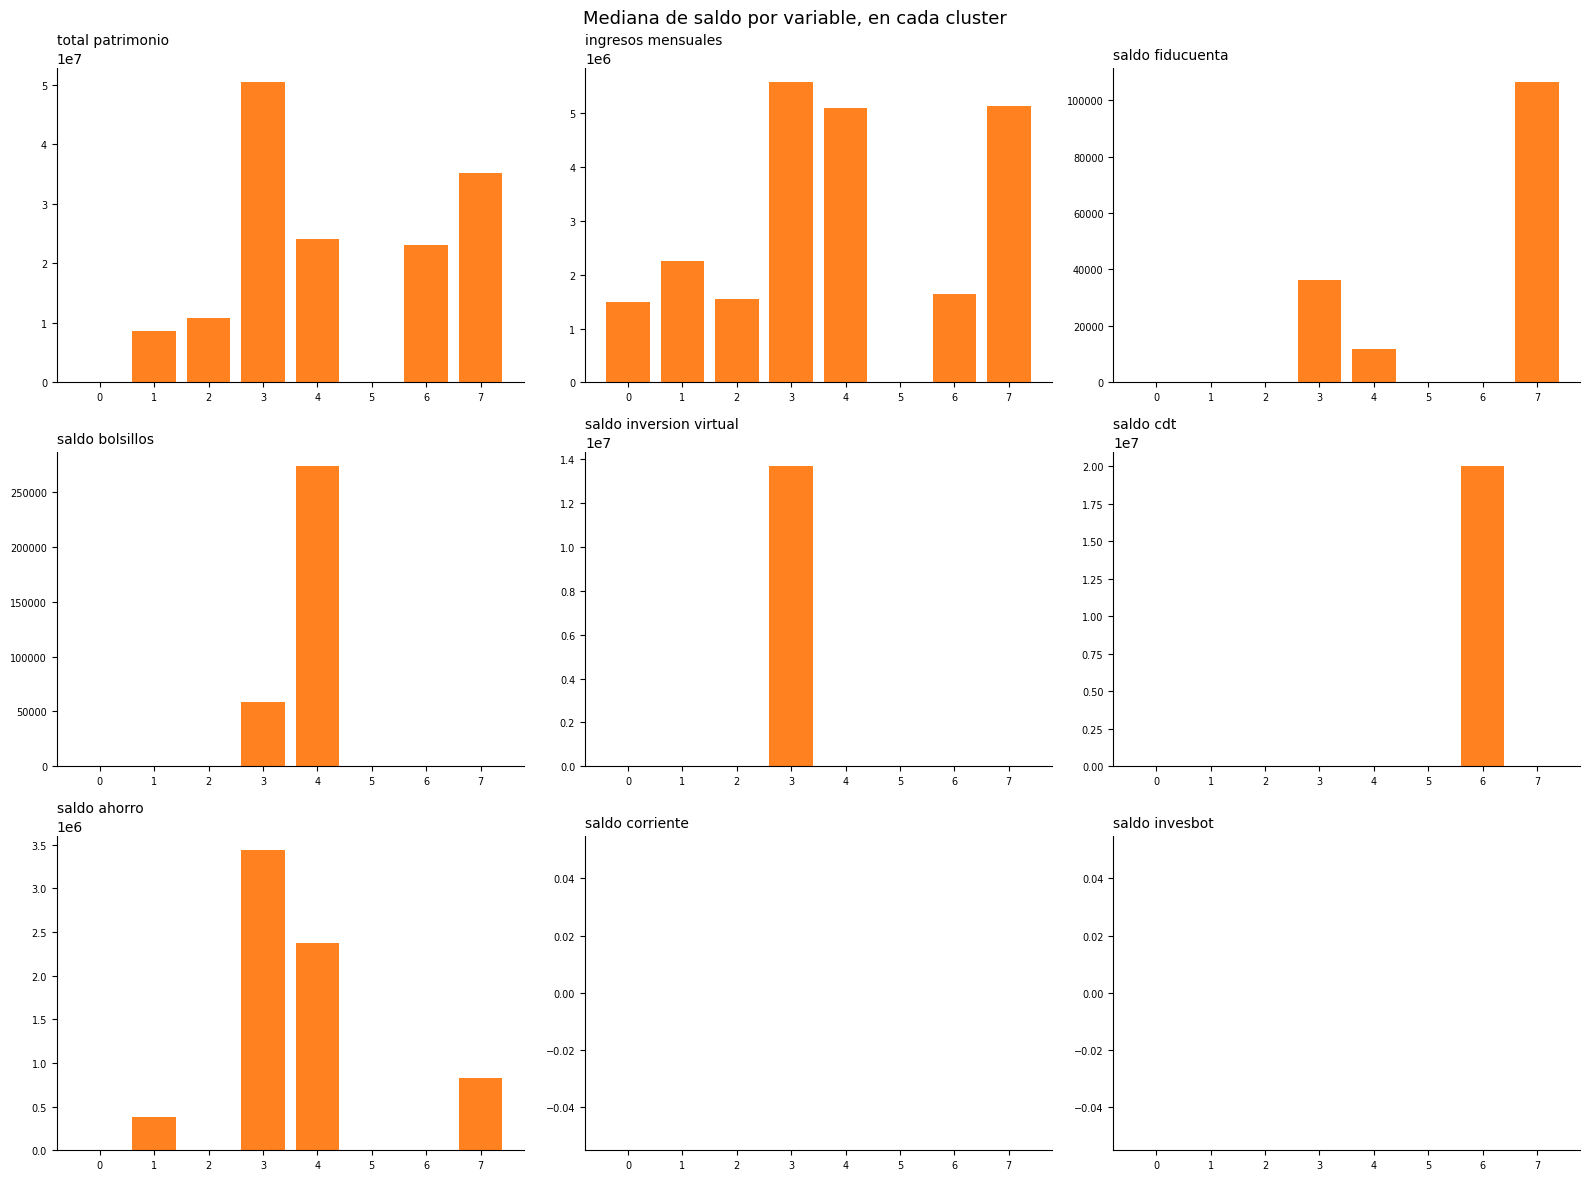

In [ ]:
# ---------- Gráfica 2: mediana de saldo por cluster (small multiples) ----------
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for ax, col in zip(axes, cols_perfil_numericas):
    ax.bar(perfil_numerico.index.astype(str), perfil_numerico[col], color=PALETA['naranja'])
    ax.set_title(col.replace("_mediana_historica_wz", "").replace("_wz", "").replace("_", " "),
                 fontsize=10, loc="left")
    ax.tick_params(labelsize=7)
    ax.spines[["top", "right"]].set_visible(False)
plt.suptitle("Mediana de saldo por variable, en cada cluster", fontsize=13)
plt.tight_layout()
plt.savefig("mediana_saldo_por_cluster.png", dpi=110)
plt.show()

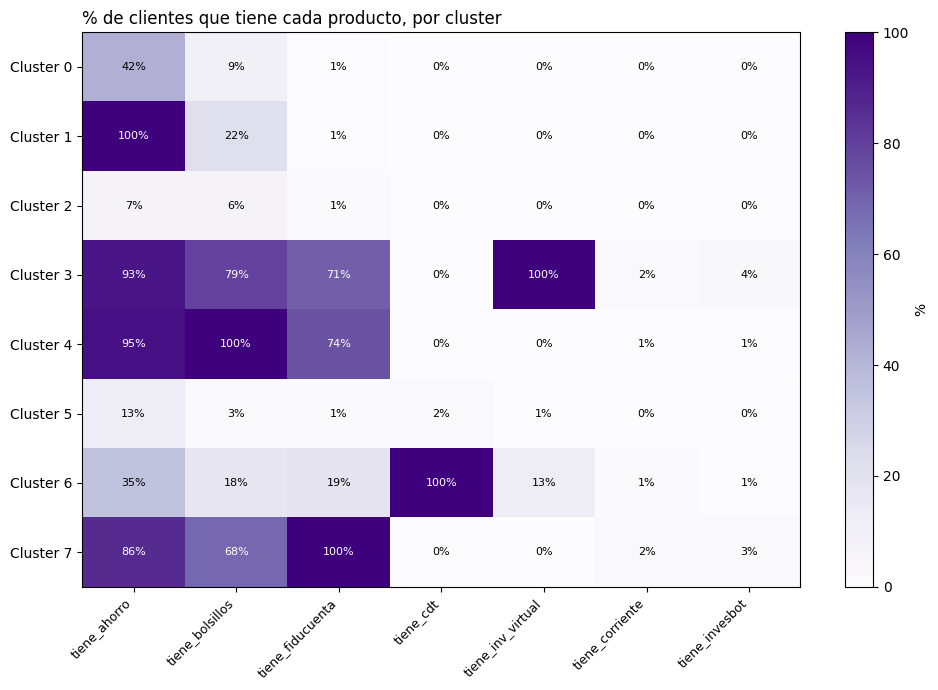

In [ ]:
# ---------- Gráfica 3: % que tiene cada producto por cluster (heatmap) ----------
fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(perfil_binario.values, cmap="Purples", vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(len(perfil_binario.columns)))
ax.set_xticklabels(perfil_binario.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(perfil_binario.index)))
ax.set_yticklabels([f"Cluster {i}" for i in perfil_binario.index])
for i in range(perfil_binario.shape[0]):
    for j in range(perfil_binario.shape[1]):
        v = perfil_binario.values[i, j]
        ax.text(j, i, f"{v:.0f}%", ha="center", va="center", fontsize=8,
                color="white" if v > 55 else "black")
ax.set_title("% de clientes que tiene cada producto, por cluster", fontsize=12, loc="left")
plt.colorbar(im, label="%")
plt.tight_layout()
plt.savefig("heatmap_tenencia_clusters.png", dpi=110)
plt.show()

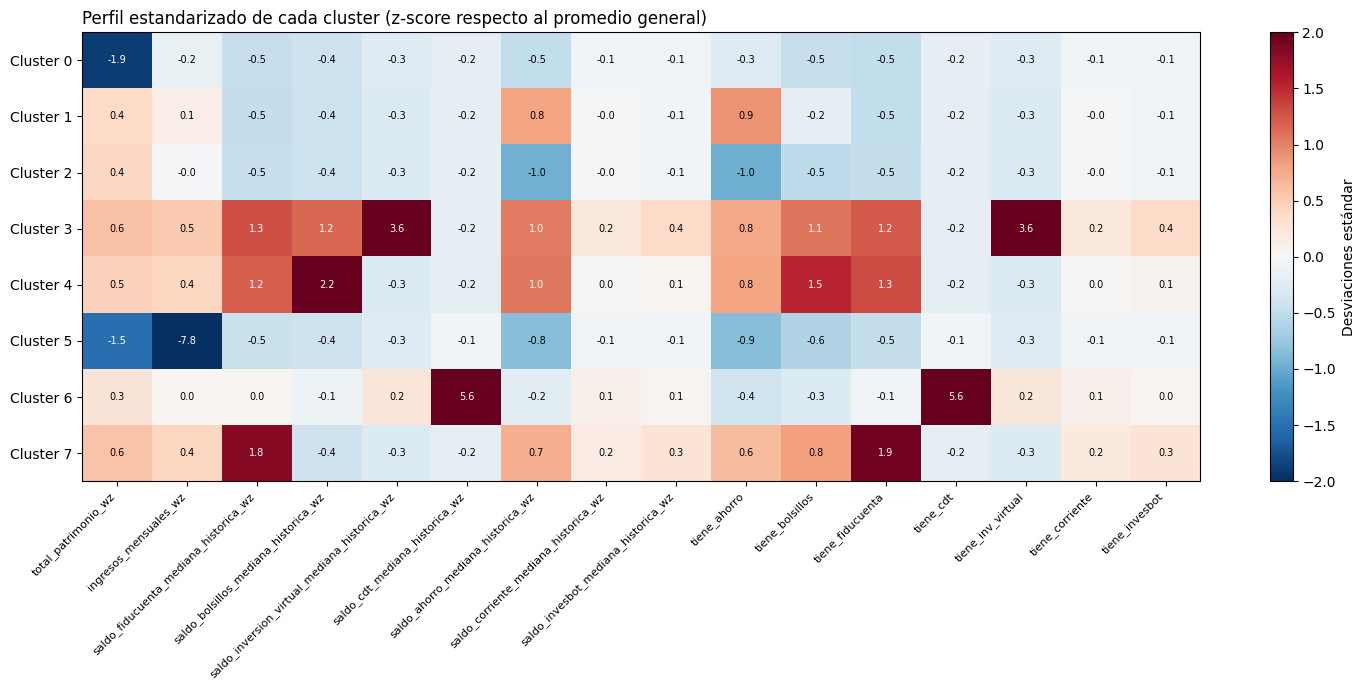

In [ ]:
df_z = pd.DataFrame(index=df_abt_crean.index)
for col in cols_perfil_numericas:
    log_col = np.log1p(df_abt_crean[col].clip(lower=0))
    df_z[col] = (log_col - log_col.mean()) / log_col.std()
for col in cols_perfil_binarias:
    df_z[col] = (df_abt_crean[col] - df_abt_crean[col].mean()) / df_abt_crean[col].std()
df_z["cluster"] = df_abt_crean["cluster"]
heatmap_data = df_z.groupby("cluster").mean()

fig, ax = plt.subplots(figsize=(15, 7))
im = ax.imshow(heatmap_data.values, cmap="RdBu_r", vmin=-2, vmax=2, aspect="auto")
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels([f"Cluster {i}" for i in heatmap_data.index])
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        ax.text(j, i, f"{heatmap_data.values[i, j]:.1f}", ha="center", va="center", fontsize=7,
                color="white" if abs(heatmap_data.values[i, j]) > 1 else "black")
ax.set_title("Perfil estandarizado de cada cluster (z-score respecto al promedio general)",
             fontsize=12, loc="left")
plt.colorbar(im, label="Desviaciones estándar")
plt.tight_layout()
plt.savefig("perfil_heatmap_clusters.png", dpi=110)
plt.show()


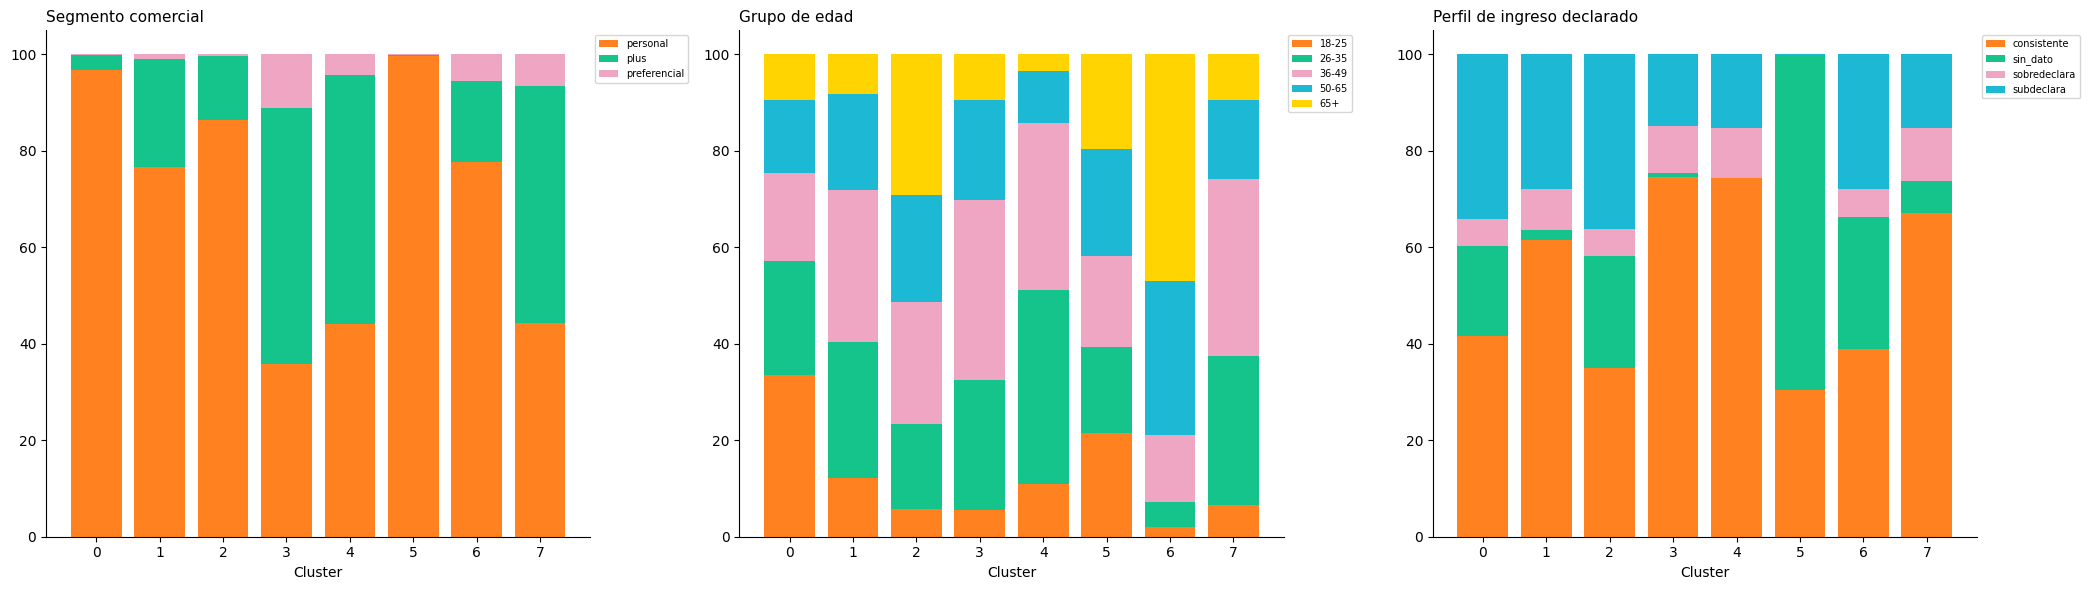

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
variables_demograficas = [("desc_segmento", "Segmento comercial"),
                           ("grupo_edad", "Grupo de edad"),
                           ("perfil_ingreso", "Perfil de ingreso declarado")]

colores_paleta = [PALETA['naranja'], PALETA['verde'], PALETA['rosa'], PALETA['azul'], PALETA['amarillo']]

for ax, (var, titulo) in zip(axes, variables_demograficas):
    cruce = pd.crosstab(df_abt_crean["cluster"], df_abt_crean[var], normalize="index") * 100
    bottom = np.zeros(len(cruce))
    for i, col in enumerate(cruce.columns):
        ax.bar(cruce.index.astype(str), cruce[col], bottom=bottom, label=col, color=colores_paleta[i % len(colores_paleta)])
        bottom += cruce[col].values
    ax.set_title(titulo, fontsize=11, loc="left")
    ax.set_xlabel("Cluster")
    ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1, 1))
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("perfil_demografico_clusters.png", dpi=110)
plt.show()

## Lectura de los clusters: perfiles de cliente

**Cluster 0 (17.7%) — Bajo perfil financiero.** El patrimonio más bajo de toda la base (la mediana prácticamente cae en 0 tras el piso que le pusimos a los negativos), ingreso bajo (~1.45M/mes), y tenencia de productos débil (42% ahorro, casi nada más). Casi todos son segmento "personal". Es el cliente con menos capacidad financiera visible.

**Cluster 1 (21.6%) — Ahorrador básico.** Se define por una sola cosa: el 100% tiene cuenta de ahorro. Patrimonio apenas positivo, sin ningún otro producto. Es el cliente bancario "de base", solo usa ahorro.

**Cluster 2 (31.7%) — El más grande, y el más "invisible".** Casi 1 de cada 3 clientes cae aquí. Tiene un patrimonio similar al de Cluster 1, pero casi sin productos (7% ahorro, 6% bolsillos, el resto en cero). No es que no tenga plata — es que no se refleja en ningún producto con el banco. Sesga hacia edades más grandes.

**Cluster 3 (6.6%) — Inversionista digital, el más rentable.** El único cluster donde el 100% tiene inversión virtual. Además tiene bolsillos (79%), fiducuenta (71%) y ahorro (93%) — el más multiproducto de todos. Tiene el patrimonio (~50.7M) y el ingreso (~5.5M/mes) más altos de toda la base. Es el perfil "ya convertido": ya invierte digitalmente y tiene la mayor capacidad.

**Cluster 4 (12.0%) — Ahorrador organizado.** Se define por bolsillos: 100% lo tiene, y además tiene ahorro (95%) y fiducuenta (74%) — pero nada de CDT ni inversión virtual. Segundo ingreso más alto (~5.1M/mes). Usa el banco activamente para organizar su plata, pero todavía no ha dado el salto a un producto formal de inversión — candidato fuerte para la nueva app.

**Cluster 5 (1.3%) — El atípico: no es pobre, es un vacío de dato.** El más chico de todos. Su ingreso mensual reportado está prácticamente en cero — es, por lejos, el valor más extremo de toda la tabla (-7.8 desviaciones estándar del promedio, cuando ningún otro cluster pasa de -2). Coincide con el segmento "sin_dato" de perfil de ingreso: no es necesariamente un cliente de bajos recursos reales, es un cliente del que el banco casi no tiene información financiera declarada.

**Cluster 6 (3.0%) — El cliente de CDT.** El único cluster donde el 100% tiene CDT, pero con tenencia baja de todo lo demás (35% ahorro, 18% bolsillos, 19% fiducuenta) — un perfil más cerrado, invierte en CDT y poco más. Coincide con algo que ya se había visto antes: CDT es el producto más "solitario" de todo el banco, y más asociado a clientes mayores (el grupo de edad de este cluster confirma ese sesgo).

**Cluster 7 (6.0%) — El cliente de fiducuenta.** Se define por tener fiducuenta al 100%, con el saldo de fiducuenta más alto de toda la base (más del doble que Cluster 3). También tiene ahorro (86%) y bolsillos (68%) altos. Ingreso (~5.15M) y patrimonio (~35.6M) altos — otro perfil sólido, ya bancarizado en profundidad.

### Lo que esto dice del negocio

- **El 71% de la base (clusters 0, 1 y 2) tiene poco o ningún producto** — confirma con evidencia directa lo que ya se había visto al principio del notebook: la oportunidad más grande no está en vender más a quien ya invierte, está en activar a esta mayoría silenciosa.
- **Quien ya invierte, invierte en un solo producto, no en varios** — los clusters 3, 4, 6 y 7 se definen cada uno por tener el 100% de UN producto específico (inversión virtual, bolsillos, CDT, fiducuenta respectivamente), no por combinaciones. Hay una oportunidad de venta cruzada dentro de la base ya activa, no solo de conversión de cero a uno.
- **Los clusters 3, 4 y 7 son el segmento más sano del banco** — alto patrimonio, alto ingreso, ya usan el banco activamente. El 6 (CDT) es distinto: también "invierte", pero con un patrimonio más moderado y un perfil más tradicional/mayor.
- **Cluster 5 necesita tratamiento aparte** — no es un segmento de comportamiento, es una bandera de calidad de dato. Antes de targetearlo comercialmente, probablemente valga más la pena conseguir mejor información financiera de esos clientes.
- **Los mejores candidatos inmediatos para la app son Cluster 2 (el más grande, con capacidad pero sin activar) y Clusters 4/7 (ya comprometidos con el banco, con plata, pero sin producto de inversión formal todavía).**

## Resumen de supuestos

### **Selección de variables**
1. Se agrupa por comportamiento financiero, no por quién es el cliente: `grupo_edad`, `desc_genero` y `desc_tipo_de_vivienda` quedan fuera de la distancia a propósito, para que K-means no termine agrupando por generación o género en vez de por comportamiento.
2. `desc_segmento` no entra porque es circular: es una segmentación que el banco ya deriva del patrimonio/ingreso del cliente, así que usarla como input sería redescubrir con otro nombre algo que ya existe. Se reserva para perfilar los clusters después.
3. La metadata de calidad (`min`, `max`, `n_snapshots`, `confianza_historia`, etc.) se trata como "qué tan confiable es el dato", no como comportamiento financiero, y por eso queda fuera.
4. A quien no tiene un producto se le asume saldo 0, no dato faltante, para que todos los clientes queden en la misma escala comparable.
5. Bolsillos se mantiene como señal de comportamiento de inversión, aunque no es un producto formal de inversión — se decide así porque de todas formas refleja cómo el cliente maneja su plata.

### **Umbrales:**
6. Un flag se considera redundante frente a su saldo cuando correlacionan ≥0.9 — por encima de eso, se asume que el saldo ya contiene la información del flag.
7. Una bandera se considera demasiado desbalanceada para aportar cuando su varianza de Bernoulli cae por debajo de 0.02 (equivalente a una prevalencia fuera del rango ~2%-98%).
8. Los valores extremos de patrimonio y saldo se recortan al percentil 99, calculado solo entre quienes tienen el producto — se asume que ahí termina el comportamiento normal y empieza el outlier.

### **Tratamiento del dato:**
9. Patrimonio o saldo negativo se trata como capacidad de inversión ≈ 0 — una lectura de negocio, no un hecho matemático: se decide no modelar el valor real de la deuda neta.
10. Las variables binarias no se escalan porque ya están en un rango comparable (0/1), sin ajustar formalmente su varianza frente a las continuas estandarizadas.
11. La búsqueda de k se apoya en una muestra de 50,000 clientes, asumida representativa de los 860,223 — el supuesto se valida después (estabilidad entre semillas, comparación contra la población completa), pero es el punto de partida.

### **El modelo**
12. Se parte de que K-means (distancia euclidiana, clusters de forma esférica) es el algoritmo adecuado para este problema — un supuesto que se pone a prueba más adelante contra un Gaussian Mixture Model.
13. k=8 se elige dentro de un rango que se asume manejable para negocio (4 a 8 grupos), no por el óptimo puramente estadístico — un k mayor podría dar mejor silhouette.
14. `saldo_corriente` y `saldo_invesbot` se excluyen de la distancia porque se asume que su prevalencia extrema genera separación artificial, no señal real; se conservan solo para perfilar los clusters ya formados.

### **Definiciones de negocio**
15. "Prospecto prioritario" se define como un cliente sin fiducuenta, CDT, inversión virtual ni invesbot, con patrimonio en el 10% más alto — una definición entre varias posibles (por ejemplo, no cuenta tener bolsillos como "ya invertir").
16. Una brecha de hasta ±30% entre el ingreso declarado y el estimado se asume como "consistente"; por fuera de ese rango se considera que el cliente subdeclara o sobredeclara.

In [ ]:
db_path_output = '/content/drive/MyDrive/df_abt_crean_con_clusters.db'
conn_output = sqlite3.connect(db_path_output)
df_abt_crean.to_sql('abt_crean_clusters', conn_output, if_exists='replace', index=False)
conn_output.close()

print(f"DataFrame 'df_abt_crean' con clusters guardado en: {db_path_output}")

DataFrame 'df_abt_crean' con clusters guardado en: /content/drive/MyDrive/df_abt_crean_con_clusters.db
